# **GeoMarket AI — Notebook 01: DBSCAN Spatial Clustering**

**Tujuan notebook ini:**  
Menghasilkan `cluster_id` untuk setiap titik lokasi usaha di Batam menggunakan algoritma DBSCAN berbasis kepadatan spasial. Output `cluster_id` ini akan menjadi salah satu **fitur input utama** untuk training Random Forest di notebook berikutnya.

**Ringkasan pipeline (caption per tahap):**
- **Tahap 1** — Install & import library
- **Tahap 2** — EDA: scan file, cek skema, mapping kolom, merge data, verifikasi
- **Tahap 3** — Konfigurasi & konstanta (parameter DBSCAN dan path)
- **Tahap 4** — Ingestion & validation gate (data quality report)
- **Tahap 5** — Preprocessing & konversi koordinat (WGS84 -> UTM)
- **Tahap 6** — DBSCAN clustering + evaluasi + fitur turunan
- **Tahap 7** — Visualisasi hasil clustering & tuning EPS
- **Tahap 8** — Simpan ke feature store
- **Tahap 9** — Quality gate DBSCAN
- **Tahap 10** — Random Forest training (label proxy + evaluasi + SHAP)

**Posisi dalam MLOps Pipeline:**
```
SQLite (.db)
    └─ [01] Ingestion & Validation        <- tahap 1-2
    └─ [02] Preprocessing & Feature Eng   <- tahap 3
    └─ [03] DBSCAN Clustering             <- tahap 4-5  (inti notebook ini)
    └─ [04] Simpan ke Feature Store       <- tahap 6
            └─ [Notebook 02] Random Forest Training
```

**Mengapa DBSCAN harus jalan SEBELUM Random Forest?**  
Karena `cluster_id` dan `dist_to_cluster_centroid_m` adalah fitur yang hanya bisa dihasilkan setelah clustering selesai. Random Forest tidak bisa dilatih tanpa kedua fitur ini.

---
| Info | Detail |
|---|---|
| Proyek | GeoMarket AI — IF-4PD-04 |
| Algoritma | DBSCAN (Density-Based Spatial Clustering of Applications with Noise) |
| Library utama | `scikit-learn`, `geopandas`, `pyproj`, `pandas`, `matplotlib` |
| Input | `data/raw/{.db}` (SQLite) |
| Output | `data/processed/feature_store.csv` |

---
# Tahap 1 — Install & Import Library

Kita butuh beberapa library tambahan di luar standard library Python:
- `geopandas` + `pyproj` → untuk konversi koordinat dari derajat (WGS84) ke meter (UTM), wajib untuk perhitungan radius yang akurat
- `scikit-learn` → untuk DBSCAN dan metrik evaluasi clustering
- `scipy` → untuk perhitungan jarak spasial
- `folium` → opsional, untuk visualisasi peta interaktif

In [2]:
%pip install scikit-learn matplotlib geopandas pyproj folium seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── Core ──────────────────────────────────────────────────────────────
import sqlite3
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Geospasial ────────────────────────────────────────────────────────
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point

# ── Machine Learning ──────────────────────────────────────────────────
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# ── Visualisasi ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# Cek versi
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"geopandas   : {gpd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print("\n✓ Semua library berhasil diimport")

pandas      : 3.0.2
numpy       : 2.4.4
geopandas   : 1.1.3
scikit-learn: 1.8.0

✓ Semua library berhasil diimport


# Tahap 2 - Exploratory Data Analysis (EDA)

Tujuan: memahami struktur data, skema, dan sebaran awal sebelum validasi.

## 2.1 Scan file dataset .db

Ringkas: daftar file, kategori, dan ukuran untuk memastikan input lengkap.

In [4]:
import os
import glob

# ── Konfigurasi folder ────────────────────────────────────────────────
DB_FOLDER = "content/data/raw"

CATEGORY_MAPPING = {
    "Indonesia.Batam.Kuliner.202406162232"       : "F&B",
    "Indonesia.Batam.Kesehatan.202408050759"     : "Healthcare",
    "Indonesia.Batam.Hotel.202408042041"         : "Hospitality",
    "Indonesia.Batam.PT.202408042212"            : "Company",
    "Indonesia.Batam.School.202408060757"        : "Education",
    "Indonesia.Batam.Toko Bangunan.202408021219" : "Retail",
    "Indonesia.Batam.Cosmetics.202410290644"     : "Retail",
    "Indonesia.Batam.Toko Komputer.202410170720" : "Retail",
}

# ── Scan semua file .db ───────────────────────────────────────────────
db_files = sorted(glob.glob(os.path.join(DB_FOLDER, "*.db")))

if not db_files:
    print(f"⚠ Tidak ada file .db ditemukan di folder: {DB_FOLDER}")
    print("  Pastikan path DB_FOLDER sudah benar.")
else:
    print(f"✓ Ditemukan {len(db_files)} file .db:\n")

    unmapped = []  # tracking file yang belum ada di CATEGORY_MAPPING

    for f in db_files:
        filename    = os.path.basename(f)
        file_key    = filename.replace(".db", "")   # key untuk lookup mapping
        size_kb     = os.path.getsize(f) / 1024

        # Lookup ke CATEGORY_MAPPING
        # Jika tidak ditemukan → fallback ke bagian ke-2 dari nama file
        if file_key in CATEGORY_MAPPING:
            kategori = CATEGORY_MAPPING[file_key]
            status   = "✓"
        else:
            # Fallback: ekstrak dari nama file seperti sebelumnya
            parts    = file_key.split(".")
            kategori = parts[2] if len(parts) >= 3 else "Unknown"
            status   = "⚠"
            unmapped.append(file_key)

        print(f"  {status} {filename:<47} → {kategori:<15} ({size_kb:.1f} KB)")

    # Ringkasan mapping
    mapped_cats = {}
    for f in db_files:
        key = os.path.basename(f).replace(".db", "")
        cat = CATEGORY_MAPPING.get(key, "Unknown")
        mapped_cats.setdefault(cat, []).append(key)

    print(f"\n  Distribusi kategori setelah mapping:")
    for cat, files in sorted(mapped_cats.items()):
        print(f"    {cat:<15} ← {len(files)} file  {files}")

    if unmapped:
        print(f"\n  ⚠ File belum ada di CATEGORY_MAPPING ({len(unmapped)} file):")
        for u in unmapped:
            print(f"    → '{u}'")
        print("    Tambahkan ke CATEGORY_MAPPING atau akan menggunakan fallback nama file.")
    else:
        print(f"\n  ✓ Semua file terpetakan ke CATEGORY_MAPPING")

✓ Ditemukan 8 file .db:

  ✓ Indonesia.Batam.Cosmetics.202410290644.db       → Retail          (700.0 KB)
  ✓ Indonesia.Batam.Hotel.202408042041.db           → Hospitality     (720.0 KB)
  ✓ Indonesia.Batam.Kesehatan.202408050759.db       → Healthcare      (1332.0 KB)
  ✓ Indonesia.Batam.Kuliner.202406162232.db         → F&B             (4080.0 KB)
  ✓ Indonesia.Batam.PT.202408042212.db              → Company         (752.0 KB)
  ✓ Indonesia.Batam.School.202408060757.db          → Education       (1020.0 KB)
  ✓ Indonesia.Batam.Toko Bangunan.202408021219.db   → Retail          (780.0 KB)
  ✓ Indonesia.Batam.Toko Komputer.202410170720.db   → Retail          (364.0 KB)

  Distribusi kategori setelah mapping:
    Company         ← 1 file  ['Indonesia.Batam.PT.202408042212']
    Education       ← 1 file  ['Indonesia.Batam.School.202408060757']
    F&B             ← 1 file  ['Indonesia.Batam.Kuliner.202406162232']
    Healthcare      ← 1 file  ['Indonesia.Batam.Kesehatan.202408050759']
    

## 2.2 Peek skema tiap file

Ringkas: cek tabel user, jumlah baris, dan contoh kolom per database.

In [5]:
import sqlite3
import pandas as pd
import os
from IPython.display import display, HTML

# Daftar tabel internal SQLite yang harus selalu dilewati
SQLITE_INTERNAL_TABLES = {'sqlite_sequence', 'sqlite_stat1', 'sqlite_stat4', 'sqlite_master'}

schema_summary = []

for db_path in db_files:
    filename = os.path.basename(db_path)
    file_key = filename.replace(".db", "")
    parts = file_key.split(".")
    kategori = CATEGORY_MAPPING.get(file_key, parts[2] if len(parts) >= 3 else "Unknown")

    conn = sqlite3.connect(db_path)

    # Ambil daftar tabel
    tables_df = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
    tables = tables_df['name'].tolist()

    # Filter tabel
    user_tables = [t for t in tables if t not in SQLITE_INTERNAL_TABLES]

    # --- HEADER FILE ---
    display(HTML(f"""
    <div style="background-color: #f8f9fa; padding: 10px; border-left: 5px solid #28a745; margin-top: 20px;">
        <span style="font-weight: bold; font-size: 16px; color: #6c757d;">File: {filename}</span><br>
        <span style="color: #6c757d;">Kategori: <b>{kategori}</b> | Tabel User: {len(user_tables)}</span>
    </div>
    """))

    for table in user_tables:
        try:
            # Ambil sampel dan jumlah baris
            df_peek = pd.read_sql(f"SELECT * FROM [{table}] LIMIT 3", conn)
            row_count = pd.read_sql(f"SELECT COUNT(*) as n FROM [{table}]", conn)['n'].iloc[0]

            schema_summary.append({
                "Filename": filename,
                "Category": kategori,
                "Table": table,
                "Rows": row_count,
                "Total Column": len(df_peek.columns)
            })

            # Tampilkan info tabel dan sampel
            print(f"\n📍 Tabel: {table} ({row_count:,} baris)")
            display(df_peek)

        except Exception as e:
            print(f"  ⚠️ Gagal baca tabel '{table}': {e}")

    conn.close()

# --- BAGIAN AKHIR: RINGKASAN SELURUH FILE ---
print("\n" + "="*60)
print("📊 RINGKASAN SCHEMA KESELURUHAN")
print("="*60)

df_final_summary = pd.DataFrame(schema_summary)

if not df_final_summary.empty:
    # Format ribuan untuk tampilan profesional
    df_final_summary['Rows'] = df_final_summary['Rows'].apply(lambda x: "{:,}".format(x))
    display(df_final_summary)
else:
    print("Tidak ada tabel user yang ditemukan.")

print(f"\n✅ Inspeksi Selesai: {len(db_files)} file diproses.")


📍 Tabel: places (579 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,43,Cindy Cosmetic (Cosmetics store),0.0,0,0,,None,"Plaza Batamindo 1st Floor, JL Letjen Suprapto,...",[],+62 770 611222,1.069968,104.02261,https://www.google.com/maps/place/Cindy+Cosmet...,0
1,60,Salsa Perfume Premium Seraya,4.9,207,0,Perfume store,None,"Nagoya Garden Phase Blok F no 14, Kampung Sera...","[{""day"": ""Saturday"", ""hours"": ""None - 18:00""},...",+62 778 453025,1.1478714,104.015145,https://www.google.com/maps/place/Salsa+Perfum...,0
2,68,Agen Resmi Minyak Kutus Kutus Batu Ampar,5.0,1,0,Health and beauty shop,None,"Sakura Garden Blok 3 No 3B RT01 RW04, Kp. Sera...","[{""day"": ""Saturday"", ""hours"": ""07:00 - 20:00""}...",+62 857-6522-4027,1.1565368,104.017022,https://www.google.com/maps/place/Agen+Resmi+M...,0



📍 Tabel: places (969 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,49,RedDoorz Premium Permata Baloi Green,3.9,10,0,,[],"Jl. Permata Baloi B3 No.5, Baloi Indah, Lubuk ...",[],+62 21 80629666,1.1308848,104.0125593,https://www.google.com/maps/place/RedDoorz+Pre...,0.0
1,85,Apartemen Permata Residenses,5.0,4,0,,[],"Jl. Permata Baloi, Baloi Indah, Kec. Lubuk Baj...",[],+62 896-8728-5063,1.127807,104.0091695,https://www.google.com/maps/place/Apartemen+Pe...,0.0
2,150,OYO 90366 Homestay 81 Baloi,3.8,5,0,,[],"Jl. Permata Baloi, Baloi Indah, Kec. Lubuk Baj...",[],+62 21 29707601,1.1295187,104.0101343,https://www.google.com/maps/place/OYO+90366+Ho...,0.0



📍 Tabel: places (1,568 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,1,Posyandu Anggrek 8 Baloi Mas Indah Kel Baloi ...,5.0,1,0,Hospital,[],"Lucky View, Jalan, Baloi Indah, Kec. Lubuk Baj...",[],,1.1283252,104.0057656,https://www.google.com/maps/place/Posyandu+Ang...,-1.0
1,2,Baloi kesehatan blok b no 16,0.0,0,0,Housing complex,[],"Baloi, Jl. Bunga Raya, Baloi Indah, Kec. Lubuk...",[],,1.1304157,104.010546,https://www.google.com/maps/place/Baloi+keseha...,5.0
2,4,Klinik Kecantikan dan Anti Aging,3.3,3,0,Hospital,[],"42F8+CJ4, Baloi Indah, Lubuk Baja, Batam City,...",[],,1.1235002,104.0165641,https://www.google.com/maps/place/Klinik+Kecan...,-1.0



📍 Tabel: places (4,570 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,96,Pacific food court,4.4,233,2,Restaurant,"['Dine-in', 'Takeaway']","5222+C65, Jodoh River, Batu Ampar, Batam City,...",[],,1.151015,104.0006023,https://www.google.com/maps/place/Pacific+food...,2.0
1,193,Berjaya Masakan Padang,4.0,3,0,Padang restaurant,"['Dine-in', 'Takeaway']","5234+P57, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '09:00 – 21:00' }, { ...",,1.1542775,104.005409,https://www.google.com/maps/place/Berjaya+Masa...,0.0
2,211,Warung Kopi HARUM,4.4,303,0,Noodle shop,"['Dine-in', 'Takeaway']","5226+2HQ, Jodoh River, Batu Ampar, Batam City,...","[{ day: 'Sunday', hours: '06:00 – 14:00' }, { ...",,1.1500874,104.0114747,https://www.google.com/maps/place/Warung+Kopi+...,2.0



📍 Tabel: places (1,068 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,1,Baloi Mas Indah PT,4.2,18,0,Car dealer,[],"Ruko Baloi Mas Asri Blok Intan/16, Baloi Indah...","[{ day: 'Sunday', hours: '08:30 – 17:00' }, { ...",,1.1302276,104.0048214,https://www.google.com/maps/place/Baloi+Mas+In...,2.0
1,2,Pt Baloi 128,5.0,1,0,,[],"Jl. Bunga Raya No.128, Baloi Indah, Kec. Lubuk...",[],,1.1311342,104.0079393,https://www.google.com/maps/place/Pt+Baloi+128...,2.0
2,3,Baloi Mas Indah,4.5,102,0,Housing complex,[],"42H4+6V9, Unnamed Road, Baloi Indah, Kec. Lubu...",[],,1.1280331,104.0072354,https://www.google.com/maps/place/Baloi+Mas+In...,2.0



📍 Tabel: places (1,420 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,15,SIB Batam,5,1,0,Community college,[],"Komp.Ruko Baloi Point, Jl. Sudirman Blo.B2 No....",[],+62 852-6482-7260,1.1272635,104.0158592,https://www.google.com/maps/place/SIB+Batam/da...,3.0
1,27,Sekolah Suluh Bangsa,5,5,0,School,[],"Jl. Komp. Orchid Mas Jl. Duyung No.5, RW.6, Su...",[],,1.1566271,104.0031088,https://www.google.com/maps/place/Sekolah+Sulu...,3.0
2,36,SuksesMuda Education,0,0,0,Education center,[],"Depan Masjid Alhikmah, Jalan Baloi Kesehatan P...",[],+62 812-7076-0200,1.1304264,104.0106331,https://www.google.com/maps/place/SuksesMuda+E...,3.0



📍 Tabel: places (678 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,75,Alsin Jaya,0,0,0,Building materials store,['Delivery'],"RUKO E, Jl. Raja Ali H. No.58e, Sungai Jodoh, ...",[],,1.1534112,104.0050531,https://www.google.com/maps/place/Alsin+Jaya/d...,0.0
1,77,Mitra Tata Indah CV,0,0,0,Building materials store,['Delivery'],"Jl. Raja Ali H. No.58e, Sungai Jodoh, Kec. Bat...","[{ day: 'Friday', hours: '08:00 – 17:00' }, { ...",,1.1537469,104.0057335,https://www.google.com/maps/place/Mitra+Tata+I...,0.0
2,94,Bangunsukses Niagatama Nusantara PT,0,0,0,Building materials store,['Delivery'],"Harbour View Industrial Park Bl B/2&4, Sungai ...","[{ day: 'Friday', hours: '08:00 – 17:00' }, { ...",,1.160984,104.001689,https://www.google.com/maps/place/Bangunsukses...,0.0



📍 Tabel: places (271 baris)


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster
0,148,Asia Sunrise Persada,4,2,0,Computer store,None,"Executive Industrial Park Blok C2 No. 12 A, Ba...","[{""day"": ""Friday"", ""hours"": ""09:00 - 19:00""}, ...",+62 778 7482123,1.1119191,104.0595184,https://www.google.com/maps/place/Asia+Sunrise...,0
1,240,Rere Computer (Computer store),0,0,0,,None,"Komp. Muka Kuning Indah II, Jalan Letjen Soepr...","[{""day"": ""Friday"", ""hours"": ""09:00 - 18:00""}, ...",+62 823-8774-7805,1.0471014,103.9688311,https://www.google.com/maps/place/Rere+Compute...,0
2,273,Ben's Com,5,1,0,Computer store,None,"42R2+9W8, Jl. Duyung, Batu Selicin, Kec. Lubuk...",[],+62 811-7787-272,1.1409159,104.0023223,https://www.google.com/maps/place/Ben%27s+Com/...,0



📊 RINGKASAN SCHEMA KESELURUHAN


,Filename,Category,Table,Rows,Total Column
0,Indonesia.Batam.Cosmetics.202410290644.db,Retail,places,579,14
1,Indonesia.Batam.Hotel.202408042041.db,Hospitality,places,969,14
2,Indonesia.Batam.Kesehatan.202408050759.db,Healthcare,places,"1,568",14
3,Indonesia.Batam.Kuliner.202406162232.db,F&B,places,"4,570",14
4,Indonesia.Batam.PT.202408042212.db,Company,places,"1,068",14
5,Indonesia.Batam.School.202408060757.db,Education,places,"1,420",14
6,Indonesia.Batam.Toko Bangunan.202408021219.db,Retail,places,678,14
7,Indonesia.Batam.Toko Komputer.202410170720.db,Retail,places,271,14



✅ Inspeksi Selesai: 8 file diproses.


## 2.3 Definisi mapping kolom

Ringkas: samakan nama kolom kunci agar semua sumber konsisten.

In [6]:
# Setelah melihat output Cell 2.2, tentukan mapping nama kolom
# agar semua file memiliki nama kolom yang seragam setelah digabung.
#
# Ubah mapping di bawah sesuai hasil inspeksi Cell 2.2
# Key   = nama kolom ASLI di database
# Value = nama kolom STANDAR yang akan digunakan di Feature Store
#
# Kolom yang tidak ada di mapping akan tetap dipertahankan dengan
# nama aslinya.

COLUMN_MAPPING = {
    # Koordinat — sesuaikan jika nama kolom berbeda
    "lat"       : "latitude",
    "lng"       : "longitude",
    "lon"       : "longitude",
    "long"      : "longitude",

    # Nama tempat — sesuaikan jika nama kolom berbeda
    "nama"      : "name",
    "place_name": "name",
    "title"     : "name",

    # Kategori
    "cat"       : "category",
    "type"      : "category",
    "jenis"     : "category",

    # Rating & review
    "rate"      : "rating",
    "score"     : "rating",
    "ulasan"    : "reviews",
    "review_count": "reviews",
    "total_reviews": "reviews",

    # Tambahkan mapping lain sesuai kebutuhan
    # "nama_kolom_asli": "nama_kolom_standar",
}

# Kolom wajib yang harus ada setelah mapping
# Jika tidak ada, baris akan ditolak oleh Validation Gate
REQUIRED_COLS_FINAL = ["latitude", "longitude", "name", "category", "source_category"]

# Nama kolom latitude & longitude yang akan digunakan (setelah mapping)
LAT_COL = "latitude"
LON_COL = "longitude"
CAT_COL = "category"

print("Mapping kolom yang akan diterapkan:")
for k, v in COLUMN_MAPPING.items():
    print(f"  '{k}' → '{v}'")
print(f"\nKolom wajib setelah mapping: {REQUIRED_COLS_FINAL}")

Mapping kolom yang akan diterapkan:
  'lat' → 'latitude'
  'lng' → 'longitude'
  'lon' → 'longitude'
  'long' → 'longitude'
  'nama' → 'name'
  'place_name' → 'name'
  'title' → 'name'
  'cat' → 'category'
  'type' → 'category'
  'jenis' → 'category'
  'rate' → 'rating'
  'score' → 'rating'
  'ulasan' → 'reviews'
  'review_count' → 'reviews'
  'total_reviews' → 'reviews'

Kolom wajib setelah mapping: ['latitude', 'longitude', 'name', 'category', 'source_category']


## 2.4 Gabungkan semua .db jadi Dataframe

Ringkas: load seluruh tabel dan gabungkan ke satu DataFrame.

Memulai proses penggabungan data...

📊 LAPORAN AUDIT DATA:


,File Name,Category,Table,Rows
0,Indonesia.Batam.Cosmetics.202410290644.db,Retail,places,579
1,Indonesia.Batam.Hotel.202408042041.db,Hospitality,places,969
2,Indonesia.Batam.Kesehatan.202408050759.db,Healthcare,places,1568
3,Indonesia.Batam.Kuliner.202406162232.db,F&B,places,4570
4,Indonesia.Batam.PT.202408042212.db,Company,places,1068
5,Indonesia.Batam.School.202408060757.db,Education,places,1420
6,Indonesia.Batam.Toko Bangunan.202408021219.db,Retail,places,678
7,Indonesia.Batam.Toko Komputer.202410170720.db,Retail,places,271



JUMLAH BARIS KONSISTEN
------------------------------------------------------------
Total Baris di DataFrame : 11,123
Total Baris di File (Sum): 11,123
------------------------------------------------------------


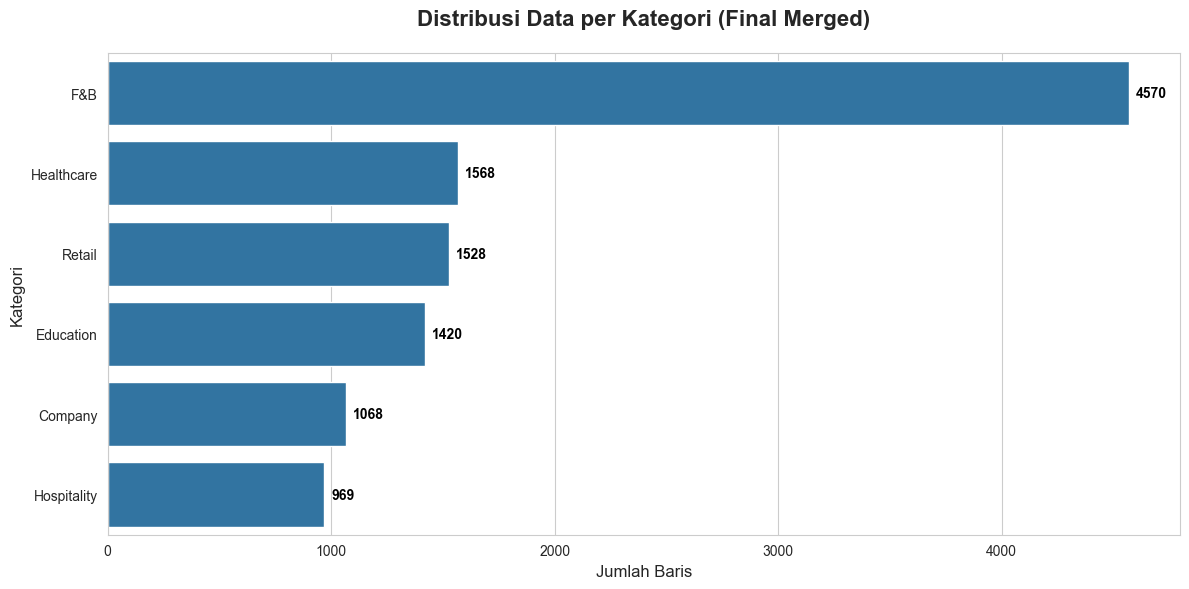

In [7]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

frames = []
load_report = []

print("Memulai proses penggabungan data...")

# --- PROSES PEMBACAAN DATA ---
for db_path in db_files:
    filename = os.path.basename(db_path)
    file_key = filename.replace(".db", "")

    # Ambil kategori (Contoh logika: mapping atau fallback)
    source_cat = CATEGORY_MAPPING.get(file_key, "Unknown")

    try:
        conn = sqlite3.connect(db_path)
        tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
        user_tables = [t for t in tables if t not in SQLITE_INTERNAL_TABLES]

        for table in user_tables:
            df_temp = pd.read_sql(f"SELECT * FROM [{table}]", conn)
            rows_before = len(df_temp)

            # Transformasi
            df_temp = df_temp.rename(columns=COLUMN_MAPPING)
            df_temp['source_category'] = source_cat
            df_temp['source_file'] = filename

            if 'category' not in df_temp.columns:
                df_temp['category'] = source_cat

            frames.append(df_temp)
            load_report.append({
                "File Name": filename,
                "Category": source_cat,
                "Table": table,
                "Rows": rows_before
            })
        conn.close()
    except Exception as e:
        print(f"Gagal memproses {filename}: {e}")

# Gabungkan Data
df_raw = pd.concat(frames, ignore_index=True)
df_report = pd.DataFrame(load_report)

# --- VISUALISASI 1: TABEL LAPORAN (Styled) ---
print("\n📊 LAPORAN AUDIT DATA:")
total_expected = df_report['Rows'].sum()
actual_rows = len(df_raw)
is_consistent = actual_rows == total_expected

display(df_report)

# --- VISUALISASI 2: STATUS INTEGRITAS (HTML Box) ---
status_color = "#d4edda" if is_consistent else "#f8d7da"
status_text = "JUMLAH BARIS KONSISTEN" if is_consistent else f"⚠️ SELISIH DATA: {abs(actual_rows - total_expected)} baris!"

print(f"\n{status_text}")
print(f"{'-'*60}")
print(f"Total Baris di DataFrame : {actual_rows:,}")
print(f"Total Baris di File (Sum): {total_expected:,}")
print(f"{'-'*60}")

# --- VISUALISASI 3: GRAFIK DISTRIBUSI (Matplotlib/Seaborn) ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Data untuk plot
dist_data = df_raw['source_category'].value_counts().reset_index()
dist_data.columns = ['Kategori', 'Jumlah']

# Buat Bar Chart Horizontal
ax = sns.barplot(x='Jumlah', y='Kategori', data=dist_data)

# Tambahkan label angka di ujung bar
for i in ax.containers:
    ax.bar_label(i, fmt='%d', padding=5, fontweight='bold', color='black')

plt.title('Distribusi Data per Kategori (Final Merged)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jumlah Baris', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.tight_layout()
plt.show()

## 2.5 Verifikasi hasil gabungan

Ringkas: cek kolom wajib, null, dan konsistensi data gabungan.

In [8]:
# Sebelum masuk ke Validation Gate (Tahap 3), pastikan:
# 1. Kolom wajib sudah ada
# 2. Tidak ada kategori yang hilang
# 3. Distribusi data masuk akal (tidak ada file yang 0 baris)

from IPython.display import display, HTML
import pandas as pd

print("Verifikasi DataFrame gabungan:\n")

# --- 1. VERIFIKASI KOLOM WAJIB ---
print("🔍 1. Verifikasi Kolom Wajib")
missing_required = [c for c in REQUIRED_COLS_FINAL if c not in df_raw.columns]

if missing_required:
    status_html = f"<span style='color:red;'><b>⚠ BELUM LENGKAP:</b> {missing_required}</span>"
else:
    status_html = "<span style='color:green;'><b>✓ SEMUA KOLOM TERSEDIA</b></span>"

display(HTML(f"Status: {status_html}<br><small>Target: {REQUIRED_COLS_FINAL}</small>"))
print("-" * 30)

# --- 2. SAMPLE PER KATEGORI (Consolidated Table) ---
print("\n🔍 2. Sampel Data per Kategori")

# Menggabungkan sampel tiap kategori ke dalam satu dataframe agar tampil sebagai satu tabel rapi
cols_to_show = [c for c in ['name', LAT_COL, LON_COL, CAT_COL, 'source_category', 'source_file'] if c in df_raw.columns]
df_sample = df_raw.groupby('source_category').head(2)[cols_to_show]
display(df_sample.reset_index(drop=True))
print("-" * 30)

# --- 3. NULL COUNT ---
print("\n🔍 3. Analisis Missing Values")
crit_cols = [c for c in REQUIRED_COLS_FINAL if c in df_raw.columns]
null_report = df_raw[crit_cols].isnull().sum().reset_index()
null_report.columns = ['Kolom', 'Jumlah Null']
null_report['Persentase'] = (null_report['Jumlah Null'] / len(df_raw) * 100).map("{:.2f}%".format)
display(null_report)

print("-" * 30)

# --- 4. RINGKASAN METADATA ---
print("\n🔍 4. Ringkasan Teknis")
info_data = {
    "Metrik": ["Shape (Baris, Kolom)", "Memory Usage", "Status Akhir"],
    "Nilai": [
        f"{df_raw.shape[0]:,} baris, {df_raw.shape[1]} kolom",
        f"{df_raw.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB",
        "SIAP VALIDASI" if not missing_required else "PERLU REVISI"
    ]
}
display(pd.DataFrame(info_data))

print("\n" + "="*40)
print("Siap masuk Tahap 3 — Validation Gate")
print("="*40)


Verifikasi DataFrame gabungan:

🔍 1. Verifikasi Kolom Wajib


------------------------------

🔍 2. Sampel Data per Kategori


,name,latitude,longitude,category,source_category,source_file
0,Cindy Cosmetic (Cosmetics store),1.069968,104.02261,,Retail,Indonesia.Batam.Cosmetics.202410290644.db
1,Salsa Perfume Premium Seraya,1.1478714,104.015145,Perfume store,Retail,Indonesia.Batam.Cosmetics.202410290644.db
2,RedDoorz Premium Permata Baloi Green,1.1308848,104.0125593,,Hospitality,Indonesia.Batam.Hotel.202408042041.db
3,Apartemen Permata Residenses,1.127807,104.0091695,,Hospitality,Indonesia.Batam.Hotel.202408042041.db
4,Posyandu Anggrek 8 Baloi Mas Indah Kel Baloi ...,1.1283252,104.0057656,Hospital,Healthcare,Indonesia.Batam.Kesehatan.202408050759.db
5,Baloi kesehatan blok b no 16,1.1304157,104.010546,Housing complex,Healthcare,Indonesia.Batam.Kesehatan.202408050759.db
6,Pacific food court,1.151015,104.0006023,Restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db
7,Berjaya Masakan Padang,1.1542775,104.005409,Padang restaurant,F&B,Indonesia.Batam.Kuliner.202406162232.db
8,Baloi Mas Indah PT,1.1302276,104.0048214,Car dealer,Company,Indonesia.Batam.PT.202408042212.db
9,Pt Baloi 128,1.1311342,104.0079393,,Company,Indonesia.Batam.PT.202408042212.db


------------------------------

🔍 3. Analisis Missing Values


,Kolom,Jumlah Null,Persentase
0,latitude,29,0.26%
1,longitude,29,0.26%
2,name,27,0.24%
3,category,27,0.24%
4,source_category,0,0.00%


------------------------------

🔍 4. Ringkasan Teknis


,Metrik,Nilai
0,"Shape (Baris, Kolom)","11,123 baris, 16 kolom"
1,Memory Usage,13.12 MB
2,Status Akhir,SIAP VALIDASI



Siap masuk Tahap 3 — Validation Gate


In [9]:
# Mengambil hanya baris yang memiliki minimal satu kolom null pada kolom kritis
df_problematic = df_raw[df_raw[crit_cols].isnull().any(axis=1)]

print(f"Ditemukan {len(df_problematic)} baris bermasalah.")
print("Berikut adalah daftar file dan tabel asalnya:")

# Tampilkan ringkasan file mana yang menyumbang null
display(df_problematic[['source_file', 'source_category']].value_counts().reset_index(name='null_count'))

# Tampilkan 10 sampel data yang kosong tersebut
display(df_problematic.head(10))


Ditemukan 29 baris bermasalah.
Berikut adalah daftar file dan tabel asalnya:


,source_file,source_category,null_count
0,Indonesia.Batam.Hotel.202408042041.db,Hospitality,27
1,Indonesia.Batam.Cosmetics.202410290644.db,Retail,2


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster,source_category,source_file
316,2332,Erto's beauty (Health and beauty shop),0.0,0,0,,None,,[],+62 858-9502-3205,NaN,NaN,https://www.google.com/maps/place/Erto%27s+bea...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
317,2333,Erto's beauty (Health and beauty shop),0.0,0,0,,None,,"[{""day"": ""Saturday"", ""hours"": ""07:00 - 00:00""}...",+62 858-9502-3205,NaN,NaN,https://www.google.com/maps/place/Erto%27s+bea...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
915,4501,NaN,0.0,0,0,NaN,NaN,"Jl. Teuku Umar No.350, Seutui, Kec. Baiturrahm...",[object Object],+62 349 71425588,NaN,NaN,https://www.google.com/maps/place/Seventeen+Ho...,0,Hospitality,Indonesia.Batam.Hotel.202408042041.db
918,4511,NaN,0.0,0,0,NaN,NaN,"Lampuyang, Pulo Aceh, Aceh Besar Regency, Aceh...",[object Object],+62 813-6002-9007,NaN,NaN,https://www.google.com/maps/place/BELIMBING+Be...,0,Hospitality,Indonesia.Batam.Hotel.202408042041.db
919,4523,NaN,0.0,0,0,NaN,NaN,"Komplek Tiban Indah Blok C No. 9, Tiban Indah,...",[object Object],+62 811-7712-199,NaN,NaN,https://www.google.com/maps/place/OYO+91195+Ma...,0,Hospitality,Indonesia.Batam.Hotel.202408042041.db
920,4524,NaN,0.0,0,0,NaN,NaN,"4XFP+2QP, Tiban Indah, Sekupang, Batam City, R...",[object Object],+62 804 104 0040,NaN,NaN,https://www.google.com/maps/place/OYO+91195+Ma...,0,Hospitality,Indonesia.Batam.Hotel.202408042041.db
950,4753,NaN,0.0,0,0,NaN,NaN,"Hotel Nagoya Plaza Unit B-07 Lantai 1, JL Imam...",[object Object],+62 778 456694,NaN,NaN,https://www.google.com/maps/place/Kepri+Global...,0,Hospitality,Indonesia.Batam.Hotel.202408042041.db
967,4825,NaN,0.0,0,0,NaN,NaN,"Blk. B No.16 No.16, Baloi Permai, Kec, Batam C...",[object Object],+62 817-788-016,NaN,NaN,https://www.google.com/maps/place/OYO+92989+Ba...,0,Hospitality,Indonesia.Batam.Hotel.202408042041.db
984,5001,NaN,0.0,0,0,NaN,NaN,"18, Taman Mediterania ii8 No.11, Batam City, C...",[object Object],+62 817-788-016,NaN,NaN,https://www.google.com/maps/place/SPOT+ON+9331...,0,Hospitality,Indonesia.Batam.Hotel.202408042041.db
985,5003,NaN,0.0,0,0,NaN,NaN,"6, Baloi Permai, Batam, Kepulauan Riau Batam S...",[object Object],+62 817-788-016,NaN,NaN,https://www.google.com/maps/place/SPOT+ON+9344...,0,Hospitality,Indonesia.Batam.Hotel.202408042041.db


In [10]:
# Menghapus baris yang nama atau koordinatnya kosong
df_raw_clean = df_raw.dropna(subset=['name', 'latitude', 'longitude']).copy()

print(f"Baris sebelum dibersihkan: {len(df_raw):,}")
print(f"Baris setelah dibersihkan: {len(df_raw_clean):,}")
print(f"Data dibuang: {len(df_raw) - len(df_raw_clean)} baris")

# Gunakan df_raw_clean untuk membersihkan data
df_raw = df_raw_clean

Baris sebelum dibersihkan: 11,123
Baris setelah dibersihkan: 11,094
Data dibuang: 29 baris


---
# Tahap 3 — Konfigurasi & Konstanta

Semua parameter yang mungkin perlu diubah dikumpulkan di satu tempat agar mudah di-tuning tanpa harus mencari di tengah kode.

**Parameter DBSCAN yang perlu diperhatikan:**
- `EPS_METER` → radius pencarian tetangga dalam meter. Nilai default 150m berarti "titik A dan B dianggap tetangga jika jaraknya ≤ 150 meter". Terlalu kecil = terlalu banyak noise, terlalu besar = semua jadi satu cluster.
- `MIN_SAMPLES` → jumlah minimum titik dalam radius EPS untuk membentuk cluster. Nilai 5 berarti "minimal ada 5 usaha dalam radius 150m untuk membentuk zona konsentrasi".

In [11]:
import os
import numpy as np

# ── Path ──────────────────────────────────────────────────────────────
DB_FOLDER          = "content/data/raw"
OUTPUT_DIR         = "content/data/processed"
FEATURE_STORE_PATH = f"{OUTPUT_DIR}/feature_store.csv"
METADATA_PATH      = "content/models/clustering_metadata.json"

# ── Batas wilayah Batam (Validation Gate) ────────────────────────────
# Tidak berubah — tetap digunakan untuk filter koordinat
BATAM_LAT_MIN =  1.00
BATAM_LAT_MAX =  1.30
BATAM_LON_MIN = 103.60
BATAM_LON_MAX = 104.20

# ── Parameter DBSCAN ─────────────────────────────────────────────────
# Tuning lebih lanjut menggunakan k-distance graph di Tahap 6.
EPS_METER   = 150   # radius pencarian tetangga dalam meter
MIN_SAMPLES = 10     # minimum titik untuk membentuk core point

# ── Sistem koordinat ──────────────────────────────────────────────────
CRS_WGS84  = "EPSG:4326"   # input  → derajat (lat/lon dari Google Maps)
CRS_UTM48N = "EPSG:32648"  # output → meter   (akurat untuk wilayah Batam)

# ── Radius analisis kompetitor ────────────────────────────────────────
RADIUS_500M = 500
RADIUS_1KM  = 1000

# ── Nama kolom standar (hasil mapping dari Cell 4) ────────────────────
LAT_COL = "latitude"
LON_COL = "longitude"
CAT_COL = "source_category"   # gunakan source_category

# ── Kolom wajib yang harus ada di df_raw ─────────────────────────────
REQUIRED_COLS = [LAT_COL, LON_COL, "name", CAT_COL]

# ── Seed reproduktibilitas ────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Buat direktori output ─────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("content/models", exist_ok=True)

# ── Tampilkan ringkasan konfigurasi ───────────────────────────────────
from IPython.display import display
import pandas as pd

df_config = pd.DataFrame([
    {"parameter": "DB Folder",          "nilai": DB_FOLDER},
    {"parameter": "Output Dir",         "nilai": OUTPUT_DIR},
    {"parameter": "Feature Store",      "nilai": FEATURE_STORE_PATH},
    {"parameter": "Metadata Path",      "nilai": METADATA_PATH},
    {"parameter": "Lat Col",            "nilai": LAT_COL},
    {"parameter": "Lon Col",            "nilai": LON_COL},
    {"parameter": "Category Col",       "nilai": CAT_COL},
    {"parameter": "Batam Lat Range",    "nilai": f"{BATAM_LAT_MIN} – {BATAM_LAT_MAX}"},
    {"parameter": "Batam Lon Range",    "nilai": f"{BATAM_LON_MIN} – {BATAM_LON_MAX}"},
    {"parameter": "EPS",                "nilai": f"{EPS_METER} meter"},
    {"parameter": "Min Samples",        "nilai": str(MIN_SAMPLES)},
    {"parameter": "CRS Input",          "nilai": CRS_WGS84},
    {"parameter": "CRS Output",         "nilai": CRS_UTM48N},
    {"parameter": "Radius 1",           "nilai": f"{RADIUS_500M} meter"},
    {"parameter": "Radius 2",           "nilai": f"{RADIUS_1KM} meter"},
    {"parameter": "Random Seed",        "nilai": str(RANDOM_SEED)},
])

display(df_config)

,parameter,nilai
0,DB Folder,content/data/raw
1,Output Dir,content/data/processed
2,Feature Store,content/data/processed/feature_store.csv
3,Metadata Path,content/models/clustering_metadata.json
4,Lat Col,latitude
5,Lon Col,longitude
6,Category Col,source_category
7,Batam Lat Range,1.0 – 1.3
8,Batam Lon Range,103.6 – 104.2
9,EPS,150 meter


---
## Tahap 4 — Ingestion & Validation Gate

**Apa yang dilakukan di sini:**  
1. Baca data dari SQLite ke DataFrame
2. Periksa skema dan tipe data
3. Jalankan Validation Gate — filter data yang tidak valid
4. Hasilkan Data Quality Report

**Mengapa Validation Gate penting sebelum clustering?**  
DBSCAN sangat sensitif terhadap outlier koordinat. Satu titik dengan lat/lon salah (misalnya `0.0, 0.0`) akan membuat satu cluster tersendiri yang tidak bermakna dan merusak hasil seluruh clustering.

Data berhasil dimuat: 11,094 baris × 16 kolom

Ringkasan tipe data:


,kolom,tipe_data
0,id,int64
1,name,str
2,rating,float64
3,review,int64
4,price_level,int64
5,category,str
6,services,object
7,address,str
8,open_hours,str
9,phone,str



Missing values pada kolom wajib:


,kolom,jumlah_null,persentase
0,latitude,0,0.0
1,longitude,0,0.0
2,name,0,0.0
3,category,0,0.0
4,source_category,0,0.0


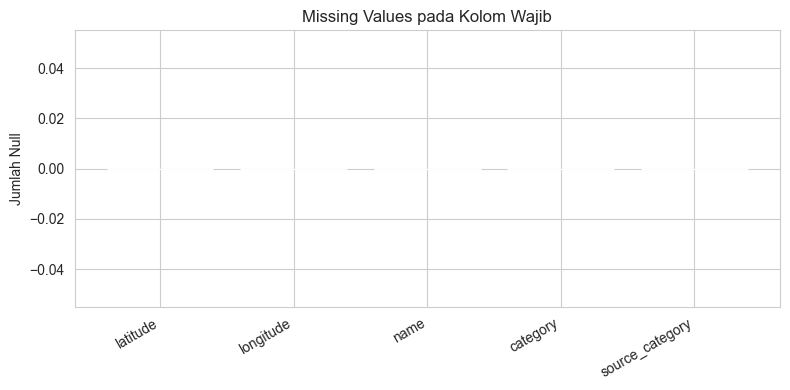


Sampel 10 baris pertama:


,id,name,rating,review,price_level,category,services,address,open_hours,phone,latitude,longitude,url,cluster,source_category,source_file
0,43,Cindy Cosmetic (Cosmetics store),0.0,0,0,,None,"Plaza Batamindo 1st Floor, JL Letjen Suprapto,...",[],+62 770 611222,1.069968,104.02261,https://www.google.com/maps/place/Cindy+Cosmet...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
1,60,Salsa Perfume Premium Seraya,4.9,207,0,Perfume store,None,"Nagoya Garden Phase Blok F no 14, Kampung Sera...","[{""day"": ""Saturday"", ""hours"": ""None - 18:00""},...",+62 778 453025,1.1478714,104.015145,https://www.google.com/maps/place/Salsa+Perfum...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
2,68,Agen Resmi Minyak Kutus Kutus Batu Ampar,5.0,1,0,Health and beauty shop,None,"Sakura Garden Blok 3 No 3B RT01 RW04, Kp. Sera...","[{""day"": ""Saturday"", ""hours"": ""07:00 - 20:00""}...",+62 857-6522-4027,1.1565368,104.017022,https://www.google.com/maps/place/Agen+Resmi+M...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
3,108,Skincare herbal SR12,5.0,1,0,Cosmetics store,None,"34H9+928, Kabil, Nongsa, Batam City, Riau Isla...","[{""day"": ""Saturday"", ""hours"": ""00:00 - 23:59""}...",+62 823-8124-9404,1.0784004,104.117568,https://www.google.com/maps/place/Skincare+her...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
4,112,Uchi parfum batu besar,4.0,2,0,Perfume store,None,"Kp Panglong, Jl. Hang Jebat Simpang Kantor Lur...","[{""day"": ""Saturday"", ""hours"": ""08:00 - 22:00""}...",+62 857-6658-9486,1.1525184,104.1287559,https://www.google.com/maps/place/Uchi+parfum+...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
5,117,Rohani Rodiarni (Cosmetics store),0.0,0,0,,None,"544J+768, Unnamed Road, Batu Besar, Kecamatan ...",[],+62 882-7113-9790,1.155661,104.130586,https://www.google.com/maps/place/Rohani+Rodia...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
6,118,Stockist AFC (Health and beauty shop),0.0,0,0,,None,"Perum Green Nongsa City, Cluster Bougenville N...","[{""day"": ""Saturday"", ""hours"": ""08:00 - 20:00""}...",+62 818-0967-3397,1.1565038,104.1160688,https://www.google.com/maps/place/Stockist+AFC...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
7,120,Tanison Mart Batu Besar - Nongsa,4.2,113,0,Grocery store,None,"542J+6XW, Batu Besar, Nongsa, Batam City, Riau...","[{""day"": ""Saturday"", ""hours"": ""07:00 - 21:00""}...",,1.1506216,104.1324562,https://www.google.com/maps/place/Tanison+Mart...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
8,198,PT Nardia Beauty Care (Beauty supply store),0.0,0,0,,None,"Grand Batam Shopping Centre, Jl. Pembangunan L...","[{""day"": ""Saturday"", ""hours"": ""10:00 - 22:00""}...",+62 852-6435-2239,1.1321035,104.0103066,https://www.google.com/maps/place/PT+Nardia+Be...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db
9,240,Golden Viera Batam,5.0,1,0,Health and beauty shop,None,"Jl. Cempaka No.286, Tj. Buntung, Kec. Bengkong...","[{""day"": ""Saturday"", ""hours"": ""10:00 - 19:00""}...",+62 895-7122-15700,1.1630796,104.0345107,https://www.google.com/maps/place/Golden+Viera...,0,Retail,Indonesia.Batam.Cosmetics.202410290644.db


In [12]:
# ── 3.1 Load data ─────────────────────────────────────────────────────
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

print(f"Data berhasil dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")

df_dtypes = df_raw.dtypes.reset_index()
df_dtypes.columns = ["kolom", "tipe_data"]
print("\nRingkasan tipe data:")
display(df_dtypes)

required_cols_view = REQUIRED_COLS_FINAL if "REQUIRED_COLS_FINAL" in globals() else REQUIRED_COLS
missing_required = [c for c in required_cols_view if c not in df_raw.columns]
if missing_required:
    print(f"⚠ Kolom wajib hilang: {missing_required}")

null_counts = df_raw[required_cols_view].isnull().sum().reset_index()
null_counts.columns = ["kolom", "jumlah_null"]
null_counts["persentase"] = (null_counts["jumlah_null"] / len(df_raw) * 100).round(2)
print("\nMissing values pada kolom wajib:")
display(null_counts)

plt.figure(figsize=(8, 4))
plt.bar(null_counts["kolom"], null_counts["jumlah_null"], color="#dc3545")
plt.title("Missing Values pada Kolom Wajib")
plt.ylabel("Jumlah Null")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nSampel 10 baris pertama:")
display(df_raw.head(10))

  konversi kolom 'latitude': str → float64
  konversi kolom 'longitude': str → float64
✓ Konversi tipe data selesai

Validation Gate — Detail per Aturan


,aturan,kolom,dibuang,sisa,dibuang_%
0,1 — Null pada kolom wajib,"latitude, longitude, name, source_category",0,11094,0.00
1,2 — Duplikat dalam file yang sama,"name, latitude, longitude, source_file",0,11094,0.00
2,3 — Duplikat lintas file (cross-file),"name, latitude, longitude",325,10769,2.93
3,4 — Rating di luar rentang 0–5,rating,1,10768,0.01



Data Quality Report


,keterangan,nilai
0,Total data masuk,11094
1,Total ditolak,326
2,Total valid,10768
3,Tingkat validitas,97.1
4,Rejection log,content/data/processed/rejected_rows.csv



Distribusi Data Valid per Kategori


,source_category,valid_rows
0,F&B,4523
1,Retail,1493
2,Healthcare,1477
3,Education,1352
4,Company,990
5,Hospitality,933


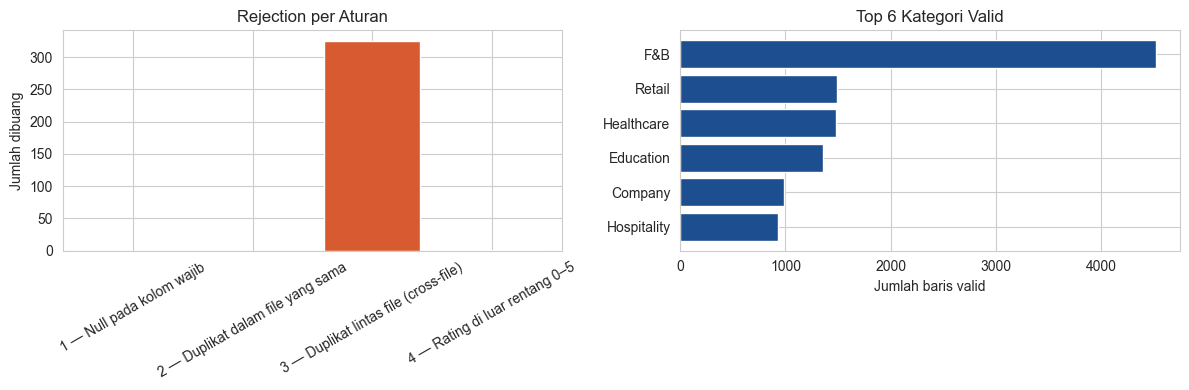


Rejection Reason Summary


,rejection_reason,count
0,duplicate_cross_file,325
1,rating_out_of_range,1


In [13]:
# ── 3.3 Validation Gate ───────────────────────────────────────────────
import matplotlib.pyplot as plt
from IPython.display import display

df            = df_raw.copy()
total_raw     = len(df)
rejection_log = []
validation_summary = []

# ─────────────────────────────────────────────────────────────────────
# PRE-STEP: Konversi tipe data kolom numerik
# ─────────────────────────────────────────────────────────────────────
# Kolom lat/lon/rating bisa tersimpan sebagai string di SQLite.
# Konversi ke numeric dulu — nilai yang tidak bisa dikonversi
# akan menjadi NaN dan tertangkap oleh Aturan 1 (null check).

numeric_cols = [LAT_COL, LON_COL]
if 'rating' in df.columns:
    numeric_cols.append('rating')

for col in numeric_cols:
    if col in df.columns:
        before = df[col].dtype
        df[col] = pd.to_numeric(df[col], errors='coerce')
        after   = df[col].dtype
        if str(before) != str(after):
            print(f"  konversi kolom '{col}': {before} → {after}")

print("✓ Konversi tipe data selesai\n")

# ─────────────────────────────────────────────────────────────────────
# Aturan 1: Kolom wajib tidak boleh null
# ─────────────────────────────────────────────────────────────────────
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(
        f"Kolom wajib tidak ditemukan di df_raw: {missing_cols}\n"
        f"Periksa COLUMN_MAPPING di Cell 4 atau REQUIRED_COLS di Tahap 2."
    )

mask_null = df[REQUIRED_COLS].isnull().any(axis=1)
null_rows = df[mask_null].copy()
null_rows['rejection_reason'] = 'null_required_column'
rejection_log.append(null_rows)
df = df[~mask_null]

validation_summary.append({
    "aturan"  : "1 — Null pada kolom wajib",
    "kolom"   : ", ".join(REQUIRED_COLS),
    "dibuang" : int(mask_null.sum()),
    "sisa"    : len(df),
})

# ─────────────────────────────────────────────────────────────────────
# Aturan 2: Duplikat dalam file yang sama
# ─────────────────────────────────────────────────────────────────────
df['_lat_r'] = df[LAT_COL].round(5)
df['_lon_r'] = df[LON_COL].round(5)

mask_dup = df.duplicated(
    subset=['name', '_lat_r', '_lon_r', 'source_file'],
    keep='first'
 )
dup_rows = df[mask_dup].copy()
dup_rows['rejection_reason'] = 'duplicate_within_file'
rejection_log.append(dup_rows)
df = df[~mask_dup]

validation_summary.append({
    "aturan"  : "2 — Duplikat dalam file yang sama",
    "kolom"   : "name, latitude, longitude, source_file",
    "dibuang" : int(mask_dup.sum()),
    "sisa"    : len(df),
})

# ─────────────────────────────────────────────────────────────────────
# Aturan 3: Duplikat lintas file (cross-file duplicate)
# ─────────────────────────────────────────────────────────────────────
mask_cross = df.duplicated(
    subset=['name', '_lat_r', '_lon_r'],
    keep='first'
 )
cross_rows = df[mask_cross].copy()
cross_rows['rejection_reason'] = 'duplicate_cross_file'
rejection_log.append(cross_rows)
df = df[~mask_cross]

validation_summary.append({
    "aturan"  : "3 — Duplikat lintas file (cross-file)",
    "kolom"   : "name, latitude, longitude",
    "dibuang" : int(mask_cross.sum()),
    "sisa"    : len(df),
})

df = df.drop(columns=['_lat_r', '_lon_r'])

# ─────────────────────────────────────────────────────────────────────
# Aturan 4: Rating harus dalam rentang wajar (0.0 – 5.0)
# ─────────────────────────────────────────────────────────────────────
if 'rating' in df.columns:
    mask_rating = (
        df['rating'].notna() &
        ~df['rating'].between(0.0, 5.0, inclusive='both')
    )
    rat_rows = df[mask_rating].copy()
    rat_rows['rejection_reason'] = 'rating_out_of_range'
    rejection_log.append(rat_rows)
    df = df[~mask_rating]

    validation_summary.append({
        "aturan"  : "4 — Rating di luar rentang 0–5",
        "kolom"   : "rating",
        "dibuang" : int(mask_rating.sum()),
        "sisa"    : len(df),
    })

# ─────────────────────────────────────────────────────────────────────
# Simpan rejection log
# ─────────────────────────────────────────────────────────────────────
valid_logs     = [r for r in rejection_log if len(r) > 0]
total_rejected = total_raw - len(df)

if valid_logs:
    df_rejected = pd.concat(valid_logs, ignore_index=True)
    df_rejected.to_csv(f"{OUTPUT_DIR}/rejected_rows.csv", index=False)
else:
    df_rejected = pd.DataFrame()

df = df.reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────
# Output terstruktur
# ─────────────────────────────────────────────────────────────────────
# Tabel 1: detail per aturan
df_val = pd.DataFrame(validation_summary)
df_val["dibuang_%"] = (df_val["dibuang"] / total_raw * 100).round(2)
print("Validation Gate — Detail per Aturan")
display(df_val)

# Tabel 2: ringkasan akhir
df_summary = pd.DataFrame([
    {"keterangan": "Total data masuk",  "nilai": total_raw},
    {"keterangan": "Total ditolak",     "nilai": total_rejected},
    {"keterangan": "Total valid",       "nilai": len(df)},
    {"keterangan": "Tingkat validitas", "nilai": round(len(df)/total_raw*100, 1)},
    {"keterangan": "Rejection log",     "nilai": f"{OUTPUT_DIR}/rejected_rows.csv"},
])
print("\nData Quality Report")
display(df_summary)

# Tabel 3: distribusi valid per kategori
df_cat_valid = (
    df.groupby(CAT_COL)
    .size()
    .reset_index(name="valid_rows")
    .sort_values("valid_rows", ascending=False)
    .reset_index(drop=True)
 )
print("\nDistribusi Data Valid per Kategori")
display(df_cat_valid)

# ── Visualisasi ringkas ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar: jumlah dibuang per aturan
axes[0].bar(df_val["aturan"], df_val["dibuang"], color="#D85A30")
axes[0].set_title("Rejection per Aturan")
axes[0].set_ylabel("Jumlah dibuang")
axes[0].tick_params(axis='x', rotation=30)

# Bar: top kategori valid
top_n = min(8, len(df_cat_valid))
axes[1].barh(df_cat_valid[CAT_COL].head(top_n), df_cat_valid["valid_rows"].head(top_n), color="#1D4E8F")
axes[1].set_title(f"Top {top_n} Kategori Valid")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah baris valid")

plt.tight_layout()
plt.show()

if not df_rejected.empty:
    reject_reason = df_rejected["rejection_reason"].value_counts().reset_index()
    reject_reason.columns = ["rejection_reason", "count"]
    print("\nRejection Reason Summary")
    display(reject_reason)

---
## Tahap 5 — Preprocessing & Konversi Koordinat

**Ini adalah langkah yang paling sering dilewatkan dan paling kritis.**

DBSCAN di scikit-learn menerima array angka sebagai input. Jika kita langsung masukkan `latitude` dan `longitude` (dalam derajat), maka:
- `eps=0.001` derajat ≈ 111 meter di garis khatulistiwa
- Tapi perbedaan jarak 1 derajat longitude di Batam (lat ~1°N) berbeda dengan di Jakarta (lat ~6°S)

**Solusi:** Konversi ke koordinat UTM Zone 48N (EPSG:32648) yang satuannya **meter** — sehingga `eps=150` benar-benar berarti 150 meter di semua arah, tanpa distorsi.

Alternatif lain adalah menggunakan `metric='haversine'` dengan input radian, tapi pendekatan UTM lebih intuitif untuk tuning parameter.

Ringkasan rentang koordinat:


,metrik,min,max
0,latitude,-3.781213e+01,3.518578e+01
1,longitude,-4.663484e+01,1.449730e+02
2,x_utm,-8.127814e+06,4.071425e+06
3,y_utm,-1.706813e+07,4.397709e+06



Sampel 10 baris pertama (WGS84 → UTM):


,latitude,longitude,x_utm,y_utm
0,1.069968,104.022610,391254.494424,118281.071759
1,1.147871,104.015145,390426.713322,126893.316018
2,1.156537,104.017022,390635.896275,127851.176922
3,1.078400,104.117568,401820.782658,119210.017305
4,1.152518,104.128756,403068.068996,127402.908756
5,1.155661,104.130586,403271.802196,127750.239905
6,1.156504,104.116069,401656.566494,127843.904668
7,1.150622,104.132456,403479.720867,127193.104669
8,1.132103,104.010307,389887.748375,125150.406650
9,1.163080,104.034511,392582.086624,128573.791263


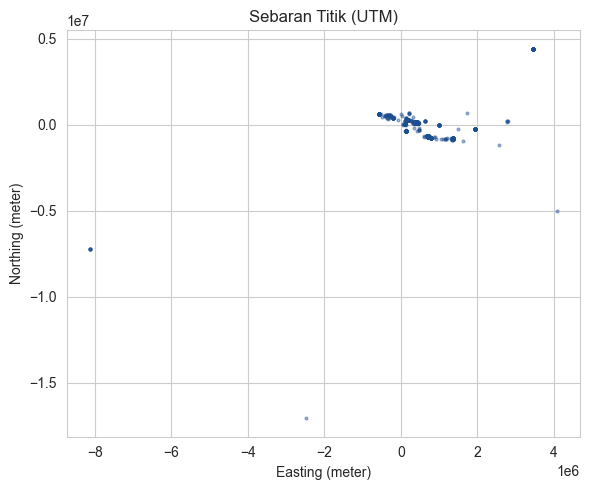

In [14]:
# ── 4.1 Konversi koordinat WGS84 → UTM Zone 48N ──────────────────────
#
# Mengapa UTM Zone 48N?
# Batam berada di zona UTM 48N (lon 102°E – 108°E, belahan utara).
# Koordinat UTM dalam satuan meter, sehingga EPS_METER langsung berarti meter.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

transformer = Transformer.from_crs(CRS_WGS84, CRS_UTM48N, always_xy=True)

# Konversi: lon dulu, baru lat (urutan 'always_xy': x=lon, y=lat)
df['x_utm'], df['y_utm'] = transformer.transform(
    df[LON_COL].values,
    df[LAT_COL].values
)

df_coords = df[[LAT_COL, LON_COL, 'x_utm', 'y_utm']].copy()
summary_ranges = pd.DataFrame([
    {"metrik": "latitude",  "min": df_coords[LAT_COL].min(), "max": df_coords[LAT_COL].max()},
    {"metrik": "longitude", "min": df_coords[LON_COL].min(), "max": df_coords[LON_COL].max()},
    {"metrik": "x_utm",     "min": df_coords['x_utm'].min(),  "max": df_coords['x_utm'].max()},
    {"metrik": "y_utm",     "min": df_coords['y_utm'].min(),  "max": df_coords['y_utm'].max()},
])

print("Ringkasan rentang koordinat:")
display(summary_ranges)

print("\nSampel 10 baris pertama (WGS84 → UTM):")
display(df_coords.head(10))

plt.figure(figsize=(6, 5))
plt.scatter(df['x_utm'], df['y_utm'], s=4, alpha=0.4, color="#1D4E8F")
plt.title("Sebaran Titik (UTM)")
plt.xlabel("Easting (meter)")
plt.ylabel("Northing (meter)")
plt.tight_layout()
plt.show()

Rating — median: 4.30, null diisi median

Ringkasan statistik fitur atribut:


,rating,review_log
count,10768.00,10768.00
mean,3.26,2.01
std,2.05,2.07
min,0.00,0.00
25%,0.00,0.00
50%,4.30,1.39
75%,4.90,3.14
max,5.00,9.97



Top 10 kategori:


,source_category,count
0,f&b,4523
1,retail,1493
2,healthcare,1477
3,education,1352
4,company,990
5,hospitality,933


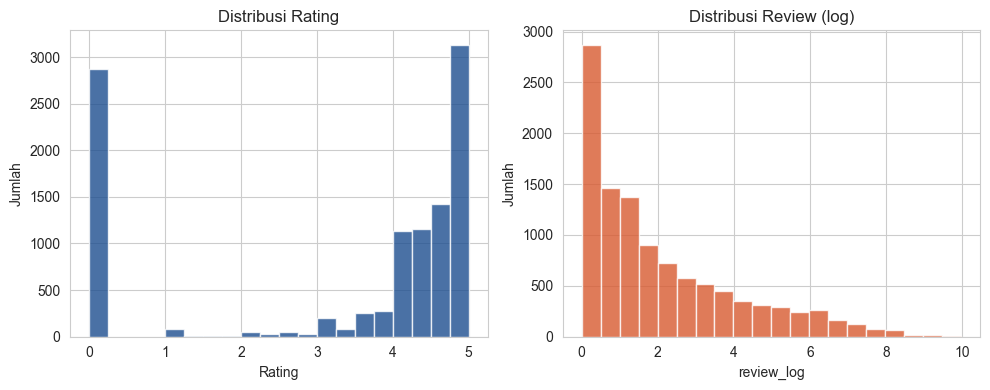


✓ Preprocessing selesai. Shape: (10768, 19)


In [15]:
# ── 4.2 Persiapan fitur atribut tambahan ─────────────────────────────
#
# Selain koordinat, kita siapkan fitur-fitur lain yang akan digunakan
# oleh Random Forest nanti. Di sini kita buat versi awalnya.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# --- review_log: transformasi log untuk mengurangi skewness ---
# Usaha dengan 10 review vs 10.000 review tidak perlu dibedakan sebesar itu
if 'reviews' in df.columns:
    df['review_log'] = np.log1p(df['reviews'])  # log(1 + x) agar x=0 tidak error
elif 'review' in df.columns:
    df['review_log'] = np.log1p(df['review'])
else:
    df['review_log'] = 0.0
    print("⚠ Kolom review tidak ditemukan, review_log diset 0")

# --- rating: isi nilai null dengan median ---
if 'rating' in df.columns:
    median_rating = df['rating'].median()
    df['rating'] = df['rating'].fillna(median_rating)
    print(f"Rating — median: {median_rating:.2f}, null diisi median")

# --- Normalisasi kategori: lowercase + strip whitespace ---
cat_col = CAT_COL if CAT_COL in df.columns else ("category" if "category" in df.columns else None)
if cat_col:
    df[cat_col] = df[cat_col].astype(str).str.lower().str.strip()
else:
    print("⚠ Kolom kategori tidak ditemukan untuk normalisasi")

summary_cols = [c for c in ['rating', 'review_log'] if c in df.columns]
if summary_cols:
    print("\nRingkasan statistik fitur atribut:")
    display(df[summary_cols].describe().round(2))

if cat_col:
    cat_counts = df[cat_col].value_counts().head(10).reset_index()
    cat_counts.columns = [cat_col, 'count']
    print("\nTop 10 kategori:")
    display(cat_counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if 'rating' in df.columns:
    axes[0].hist(df['rating'].dropna(), bins=20, color="#1D4E8F", alpha=0.8)
    axes[0].set_title("Distribusi Rating")
    axes[0].set_xlabel("Rating")
    axes[0].set_ylabel("Jumlah")
else:
    axes[0].axis("off")
    axes[0].text(0.5, 0.5, "Rating tidak tersedia", ha="center", va="center")

if 'review_log' in df.columns:
    axes[1].hist(df['review_log'].dropna(), bins=20, color="#D85A30", alpha=0.8)
    axes[1].set_title("Distribusi Review (log)")
    axes[1].set_xlabel("review_log")
    axes[1].set_ylabel("Jumlah")
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "Review tidak tersedia", ha="center", va="center")

plt.tight_layout()
plt.show()

print(f"\n✓ Preprocessing selesai. Shape: {df.shape}")

---
## Tahap 6 — DBSCAN Clustering

### Cara Kerja DBSCAN

DBSCAN mengklasifikasikan setiap titik menjadi salah satu dari tiga jenis:

| Jenis Titik | Kondisi | `cluster_id` |
|---|---|---|
| **Core point** | Punya ≥ `min_samples` tetangga dalam radius `eps` | angka ≥ 0 |
| **Border point** | Berada dalam radius `eps` core point, tapi tetangganya < `min_samples` | angka ≥ 0 (ikut cluster terdekat) |
| **Noise point** | Tidak masuk kategori keduanya | **-1** |

### Mengapa nilai -1 penting?
Titik berlabel `-1` (noise) adalah usaha yang **berdiri sendiri** — tidak ada usaha lain dalam radius `eps` yang cukup membentuk zona. Dalam konteks GeoMarket AI, ini bisa berarti:
- Lokasi terisolasi yang belum terjamah persaingan → peluang pasar
- Atau memang area yang kurang ramai secara umum

Kita **tidak membuang** titik noise — kita tetap gunakan dengan `cluster_id = -1` sebagai fitur tersendiri.

### Mengapa tidak perlu StandardScaler?
Karena input DBSCAN kita hanya dua kolom dalam satuan yang sama (meter), tidak perlu scaling. Jika kita menambahkan fitur lain (rating, dll) ke dalam input DBSCAN, barulah scaling diperlukan.

Menjalankan DBSCAN dengan eps=150m, min_samples=10...

Ringkasan DBSCAN:


,metrik,nilai
0,Jumlah cluster,118.0
1,Titik dalam cluster,6833.0
2,Titik noise (-1),3935.0
3,Noise ratio (%),36.5



Top 10 cluster terbesar:


,cluster_id,count
0,0,1219
1,3,692
2,10,444
3,2,405
4,32,342
5,11,175
6,21,155
7,12,153
8,51,147
9,27,111


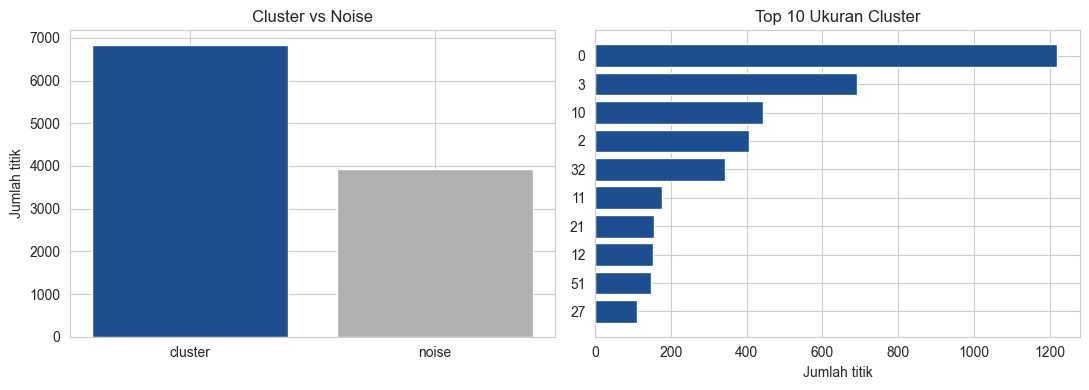

In [36]:
# ── 5.1 Jalankan DBSCAN ───────────────────────────────────────────────
#
# Input: koordinat UTM (x_utm, y_utm) dalam meter
# metric='euclidean' → jarak lurus antar titik dalam meter (akurat karena UTM)
# algorithm='ball_tree' → lebih efisien untuk data geospasial besar
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

coords_utm = df[['x_utm', 'y_utm']].values

dbscan = DBSCAN(
    eps=EPS_METER,        # radius dalam meter
    min_samples=MIN_SAMPLES,
    metric='euclidean',
    algorithm='ball_tree',
    n_jobs=-1             # gunakan semua CPU core
)

print(f"Menjalankan DBSCAN dengan eps={EPS_METER}m, min_samples={MIN_SAMPLES}...")
df['cluster_id'] = dbscan.fit_predict(coords_utm)

# ── Hasil ringkas ─────────────────────────────────────────────────────
n_clusters  = len(set(df['cluster_id'])) - (1 if -1 in df['cluster_id'].values else 0)
n_noise     = (df['cluster_id'] == -1).sum()
n_clustered = (df['cluster_id'] >= 0).sum()

summary_dbscan = pd.DataFrame([
    {"metrik": "Jumlah cluster", "nilai": n_clusters},
    {"metrik": "Titik dalam cluster", "nilai": n_clustered},
    {"metrik": "Titik noise (-1)", "nilai": n_noise},
    {"metrik": "Noise ratio (%)", "nilai": round(n_noise/len(df)*100, 1)},
])
print("\nRingkasan DBSCAN:")
display(summary_dbscan)

cluster_sizes = df[df['cluster_id'] >= 0]['cluster_id'].value_counts().reset_index()
cluster_sizes.columns = ['cluster_id', 'count']
cluster_sizes = cluster_sizes.sort_values('count', ascending=False)
print("\nTop 10 cluster terbesar:")
display(cluster_sizes.head(10))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["cluster", "noise"], [n_clustered, n_noise], color=["#1D4E8F", "#B0B0B0"])
axes[0].set_title("Cluster vs Noise")
axes[0].set_ylabel("Jumlah titik")

top_n = min(10, len(cluster_sizes))
axes[1].barh(cluster_sizes['cluster_id'].head(top_n).astype(str), cluster_sizes['count'].head(top_n), color="#1D4E8F")
axes[1].set_title(f"Top {top_n} Ukuran Cluster")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah titik")

plt.tight_layout()
plt.show()

Metrik evaluasi clustering:


,metrik,nilai,target
0,Silhouette Score,0.3424,> 0.3
1,Davies-Bouldin Index,0.5229,< 1.0


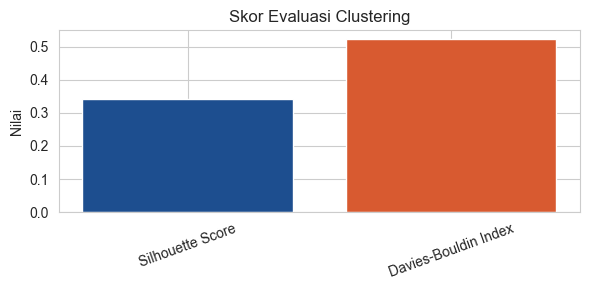

✓ Silhouette Score acceptable (0.3424)


In [17]:
# ── 5.2 Evaluasi Kualitas Clustering ─────────────────────────────────
#
# Kita gunakan DUA metrik evaluasi clustering yang disebutkan di PRD:
#
# 1. SILHOUETTE SCORE
#    Rentang: -1 hingga +1
#    +1 = cluster sangat terpisah dengan baik
#     0 = titik berada di batas antar cluster
#    -1 = titik salah cluster
#    Target: > 0.3 (acceptable), > 0.5 (good)
#
# 2. DAVIES-BOULDIN INDEX
#    Rentang: 0 hingga tak terhingga
#    Semakin KECIL semakin baik
#    0 = cluster sempurna
#    Target: < 1.0
#
# CATATAN: Kedua metrik ini hanya bisa dihitung untuk titik yang MASUK cluster
# (cluster_id >= 0). Titik noise (-1) dikecualikan.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

df_clustered = df[df['cluster_id'] >= 0]

if len(df_clustered) > 0 and n_clusters >= 2:
    X_eval = df_clustered[['x_utm', 'y_utm']].values
    y_eval = df_clustered['cluster_id'].values

    # Silhouette Score (sample untuk efisiensi jika data besar)
    sample_size = min(5000, len(df_clustered))
    sil_score = silhouette_score(
        X_eval, y_eval,
        sample_size=sample_size,
        random_state=RANDOM_SEED
    )

    # Davies-Bouldin Index
    db_score = davies_bouldin_score(X_eval, y_eval)

    metrics_df = pd.DataFrame([
        {"metrik": "Silhouette Score", "nilai": round(sil_score, 4), "target": "> 0.3"},
        {"metrik": "Davies-Bouldin Index", "nilai": round(db_score, 4), "target": "< 1.0"},
    ])
    print("Metrik evaluasi clustering:")
    display(metrics_df)

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(metrics_df["metrik"], metrics_df["nilai"], color=["#1D4E8F", "#D85A30"])
    ax.set_title("Skor Evaluasi Clustering")
    ax.set_ylabel("Nilai")
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

    if sil_score < 0.3:
        print("⚠ Silhouette Score di bawah 0.3.")
        print("  → Coba kurangi EPS_METER (cluster terlalu besar/overlap)")
        print("  → Atau kurangi MIN_SAMPLES jika terlalu banyak noise")
    else:
        print(f"✓ Silhouette Score acceptable ({sil_score:.4f})")
else:
    sil_score = None
    db_score  = None
    print("⚠ Tidak cukup cluster untuk menghitung metrik. Coba kecilkan EPS atau MIN_SAMPLES.")

Statistik jarak ke centroid:


count    6833.00
mean      396.75
std       358.49
min         0.00
25%       128.07
50%       269.74
75%       579.05
max      1845.60
Name: dist_to_cluster_centroid_m, dtype: float64

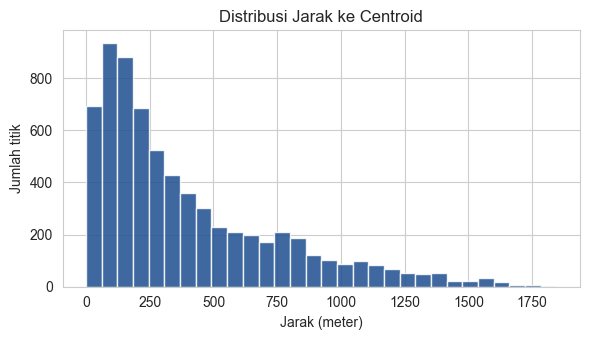


Contoh 5 baris dengan kolom baru:


,name,cluster_id,dist_to_cluster_centroid_m
0,Cindy Cosmetic (Cosmetics store),-1,0.000000
1,Salsa Perfume Premium Seraya,0,477.405770
2,Agen Resmi Minyak Kutus Kutus Batu Ampar,-1,0.000000
3,Skincare herbal SR12,-1,0.000000
4,Uchi parfum batu besar,1,417.357706


In [18]:
# ── 5.3 Hitung Centroid per Cluster & Jarak ke Centroid ───────────────
#
# Centroid = titik pusat rata-rata koordinat UTM setiap cluster.
# 'dist_to_cluster_centroid_m' adalah fitur penting untuk Random Forest:
# makin jauh dari centroid = makin di pinggiran zona konsentrasi.
# Titik noise (cluster_id = -1) mendapat dist_to_centroid = NaN → diisi 0.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# Hitung centroid per cluster
centroids = (
    df[df['cluster_id'] >= 0]
    .groupby('cluster_id')[['x_utm', 'y_utm']]
    .mean()
    .rename(columns={'x_utm': 'centroid_x', 'y_utm': 'centroid_y'})
)

# Gabungkan centroid ke df utama
df = df.merge(centroids, on='cluster_id', how='left')

# Hitung jarak Euclidean dari setiap titik ke centroid cluster-nya
df['dist_to_cluster_centroid_m'] = np.sqrt(
    (df['x_utm'] - df['centroid_x'])**2 +
    (df['y_utm'] - df['centroid_y'])**2
).fillna(0)  # noise point → 0

# Hapus kolom centroid sementara (sudah tidak perlu disimpan di feature store)
df = df.drop(columns=['centroid_x', 'centroid_y'])

print("Statistik jarak ke centroid:")
display(df[df['cluster_id'] >= 0]['dist_to_cluster_centroid_m'].describe().round(2))

plt.figure(figsize=(6, 3.5))
plt.hist(df[df['cluster_id'] >= 0]['dist_to_cluster_centroid_m'], bins=30, color="#1D4E8F", alpha=0.85)
plt.title("Distribusi Jarak ke Centroid")
plt.xlabel("Jarak (meter)")
plt.ylabel("Jumlah titik")
plt.tight_layout()
plt.show()

print("\nContoh 5 baris dengan kolom baru:")
display(df[['name', 'cluster_id', 'dist_to_cluster_centroid_m']].head())

Menghitung competitor density... (ini memerlukan beberapa detik)

Statistik fitur density:


,competitor_density_500m,competitor_density_1km,same_category_density_500m,nearest_neighbor_dist_m
count,10768.00,10768.00,10768.00,10768.00
mean,91.52,270.42,28.16,2014.19
std,91.20,254.16,36.96,117280.83
min,0.00,0.00,0.00,0.00
25%,25.00,86.00,5.00,8.95
50%,64.00,200.00,15.00,27.41
75%,130.00,368.00,34.00,66.16
max,446.00,1123.00,229.00,11348473.79


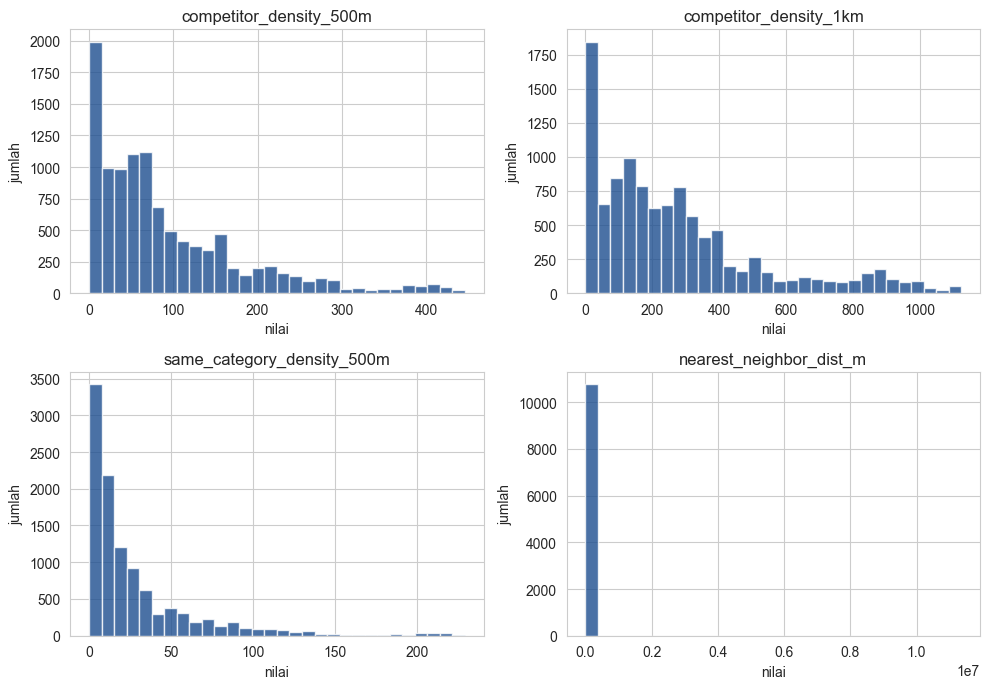

In [19]:
# ── 5.4 Hitung Fitur Density (Kompetitor dalam Radius) ────────────────
#
# Ini adalah dua fitur geospasial paling penting untuk Random Forest:
#   - competitor_density_500m: semua usaha dalam 500m
#   - same_category_density_500m: usaha kategori SAMA dalam 500m
#
# Cara kerja:
# Untuk setiap titik A, hitung berapa titik lain yang jaraknya ≤ radius.
# Kita gunakan BallTree dari scikit-learn untuk efisiensi O(n log n).
# Tanpa BallTree, kompleksitasnya O(n²) — sangat lambat untuk 75k+ titik.
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

coords_for_tree = df[['x_utm', 'y_utm']].values
tree = BallTree(coords_for_tree, metric='euclidean')

print("Menghitung competitor density... (ini memerlukan beberapa detik)")

# --- competitor_density_500m: semua usaha dalam 500m (termasuk diri sendiri) ---
counts_500m = tree.query_radius(coords_for_tree, r=RADIUS_500M, count_only=True)
# Kurangi 1 karena setiap titik menghitung dirinya sendiri
df['competitor_density_500m'] = counts_500m - 1

# --- competitor_density_1km: semua usaha dalam 1km ---
counts_1km = tree.query_radius(coords_for_tree, r=RADIUS_1KM, count_only=True)
df['competitor_density_1km'] = counts_1km - 1

# --- same_category_density_500m: usaha kategori sama dalam 500m ---
# Dilakukan per kategori untuk efisiensi
df['same_category_density_500m'] = 0

if CAT_COL in df.columns:
    for cat in df[CAT_COL].unique():
        cat_mask  = df[CAT_COL] == cat
        cat_coords = df.loc[cat_mask, ['x_utm', 'y_utm']].values

        if len(cat_coords) < 2:
            continue

        cat_tree   = BallTree(cat_coords, metric='euclidean')
        cat_counts = cat_tree.query_radius(cat_coords, r=RADIUS_500M, count_only=True)
        df.loc[cat_mask, 'same_category_density_500m'] = cat_counts - 1

# --- nearest_neighbor_dist_m: jarak ke usaha terdekat ---
# k=2 karena k=1 adalah titik itu sendiri (jarak=0)
dist_nn, _ = tree.query(coords_for_tree, k=2)
df['nearest_neighbor_dist_m'] = dist_nn[:, 1]  # ambil tetangga ke-2 (bukan diri sendiri)

density_cols = [
    'competitor_density_500m',
    'competitor_density_1km',
    'same_category_density_500m',
    'nearest_neighbor_dist_m'
]
print("\nStatistik fitur density:")
display(df[density_cols].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()
for i, col in enumerate(density_cols):
    axes[i].hist(df[col], bins=30, color="#1D4E8F", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("nilai")
    axes[i].set_ylabel("jumlah")

plt.tight_layout()
plt.show()

---
## Tahap 7 — Visualisasi Hasil Clustering

Visualisasi wajib dilakukan sebelum menyimpan output. Tujuannya bukan hanya untuk laporan — tapi untuk **sanity check**: apakah cluster yang terbentuk masuk akal secara geografis?

Hal yang perlu diperiksa:
1. Apakah cluster terbentuk di area yang memang ramai? (Nagoya, Batam Center, Batu Aji)
2. Apakah titik noise (-1) menyebar di area pinggiran?
3. Apakah tidak ada cluster tunggal raksasa yang mencakup seluruh Batam? (jika ya, EPS terlalu besar)

Ringkasan hasil DBSCAN:


,metrik,nilai
0,Jumlah cluster,118.0
1,Titik dalam cluster,6833.0
2,Titik noise,3935.0
3,Noise ratio (%),36.5


Statistik ukuran cluster:


,nilai
count,118.00
mean,57.91
std,139.77
min,7.00
25%,14.00
50%,22.00
75%,46.75
max,1219.00


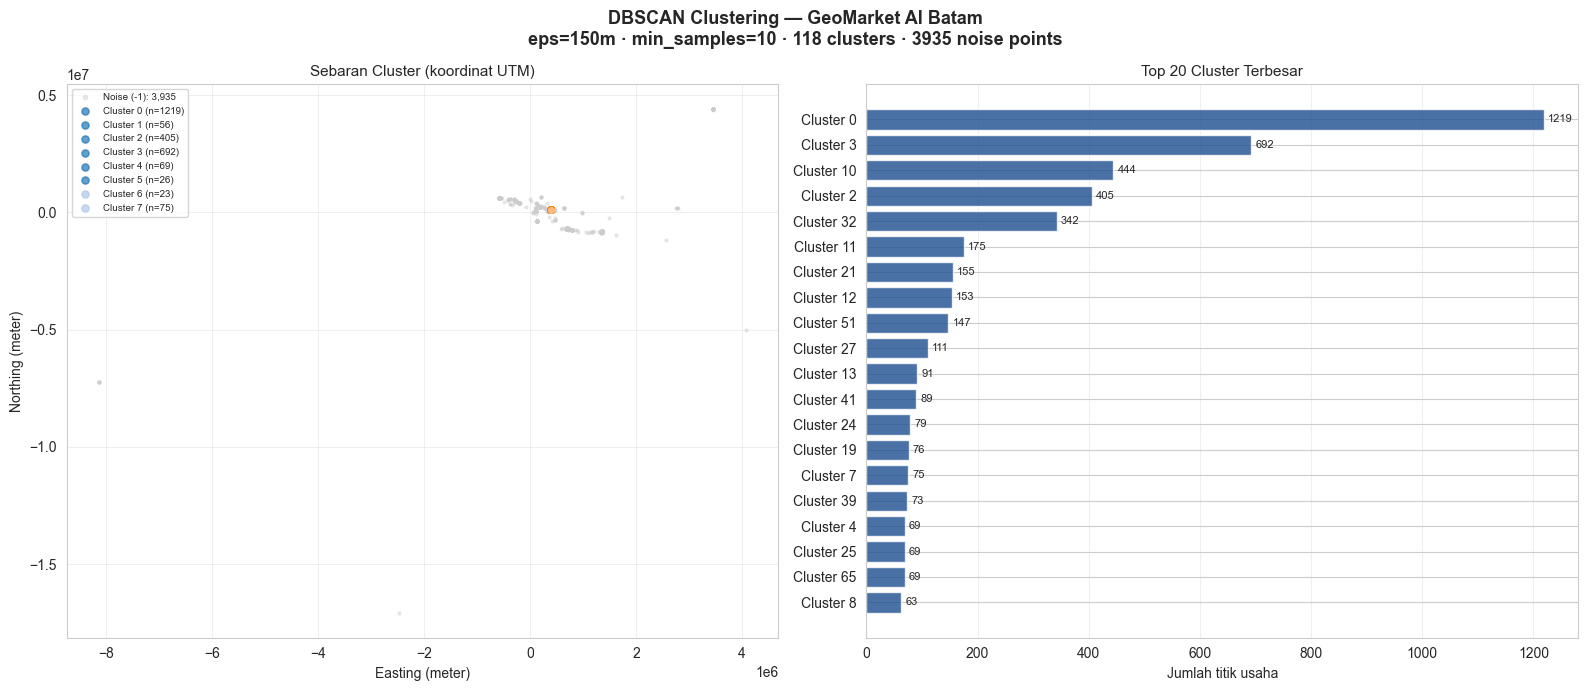

Visualisasi disimpan: content/data/processed/clustering_result.png


In [20]:
# ── 6.1 Peta Sebaran Cluster ──────────────────────────────────────────
from IPython.display import display
import pandas as pd

summary_vis = pd.DataFrame([
    {"metrik": "Jumlah cluster", "nilai": n_clusters},
    {"metrik": "Titik dalam cluster", "nilai": n_clustered},
    {"metrik": "Titik noise", "nilai": n_noise},
    {"metrik": "Noise ratio (%)", "nilai": round(n_noise / len(df) * 100, 1)},
])
print("Ringkasan hasil DBSCAN:")
display(summary_vis)

cluster_sizes_all = df[df['cluster_id'] >= 0]['cluster_id'].value_counts().sort_values(ascending=False)
cluster_stats = cluster_sizes_all.describe().round(2).to_frame(name="nilai")
print("Statistik ukuran cluster:")
display(cluster_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'DBSCAN Clustering — GeoMarket AI Batam\n'
    f'eps={EPS_METER}m · min_samples={MIN_SAMPLES} · '
    f'{n_clusters} clusters · {n_noise} noise points',
    fontsize=13, fontweight='bold'
 )

# ── Plot kiri: sebaran semua cluster dengan warna unik ────────────────
ax1 = axes[0]

# Titik noise → abu-abu kecil
noise_mask = df['cluster_id'] == -1
ax1.scatter(
    df.loc[noise_mask, 'x_utm'],
    df.loc[noise_mask, 'y_utm'],
    c='#CCCCCC', s=4, alpha=0.4, label=f'Noise (-1): {n_noise:,}', zorder=1
 )

# Titik cluster → warna berbeda per cluster
cluster_ids = sorted(df[df['cluster_id'] >= 0]['cluster_id'].unique())
colors = cm.tab20(np.linspace(0, 1, max(len(cluster_ids), 1)))

for i, cid in enumerate(cluster_ids[:20]):  # tampilkan maks 20 cluster
    mask = df['cluster_id'] == cid
    count = mask.sum()
    ax1.scatter(
        df.loc[mask, 'x_utm'],
        df.loc[mask, 'y_utm'],
        c=[colors[i]], s=12, alpha=0.7,
        label=f'Cluster {cid} (n={count})' if i < 8 else None,
        zorder=2
    )

ax1.set_title('Sebaran Cluster (koordinat UTM)', fontsize=11)
ax1.set_xlabel('Easting (meter)')
ax1.set_ylabel('Northing (meter)')
ax1.legend(loc='upper left', fontsize=7, ncol=1, markerscale=1.5)
ax1.grid(True, alpha=0.3)

# ── Plot kanan: distribusi ukuran cluster ─────────────────────────────
ax2 = axes[1]

top_n = min(20, len(cluster_sizes_all))
top_clusters = cluster_sizes_all.head(top_n)

bars = ax2.barh(
    [f'Cluster {i}' for i in top_clusters.index],
    top_clusters.values,
    color='#1D4E8F', alpha=0.8, edgecolor='white'
 )
ax2.bar_label(bars, padding=3, fontsize=8)
ax2.invert_yaxis()
ax2.set_title(f'Top {top_n} Cluster Terbesar', fontsize=11)
ax2.set_xlabel('Jumlah titik usaha')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/clustering_result.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Visualisasi disimpan: {OUTPUT_DIR}/clustering_result.png")

Ringkasan k-distance (meter):


,percentile,distance_m
0,50,145.338782
1,75,270.839658
2,90,904.185161
3,95,2119.949974
4,99,26643.285218


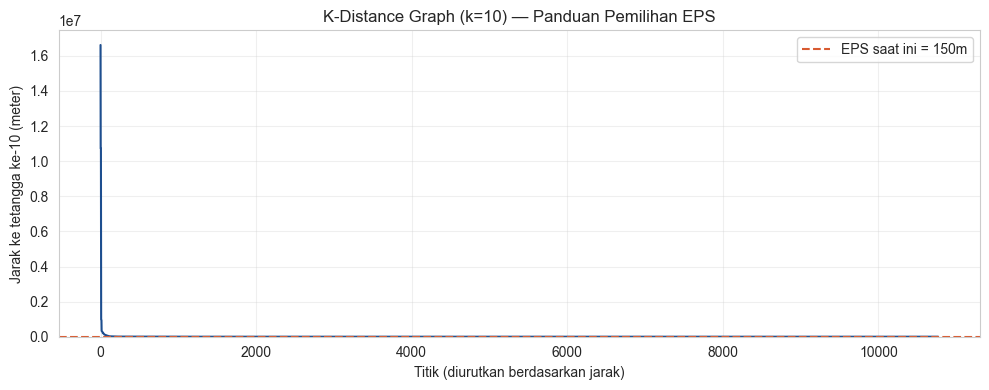


Panduan membaca grafik:
  Cari titik 'siku' (elbow) pada kurva.
  Nilai Y di titik siku tersebut adalah EPS optimal.
  EPS saat ini: 150m (garis merah putus-putus)


In [21]:
# ── 6.2 Panduan Tuning Parameter EPS ─────────────────────────────────
#
# Plot ini membantu menentukan nilai EPS yang optimal menggunakan
# metode 'k-distance graph'. Caranya:
# 1. Hitung jarak ke k tetangga terdekat untuk setiap titik
# 2. Urutkan dari besar ke kecil
# 3. EPS optimal ada di 'siku' kurva (elbow point)
#
# Nilai k = MIN_SAMPLES yang kita gunakan.
from IPython.display import display
import pandas as pd
from sklearn.neighbors import NearestNeighbors

k = MIN_SAMPLES
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean', algorithm='ball_tree')
nbrs.fit(coords_for_tree)
distances, _ = nbrs.kneighbors(coords_for_tree)

# Ambil jarak ke tetangga ke-k (kolom terakhir)
k_distances = np.sort(distances[:, -1])[::-1]

k_summary = pd.DataFrame({
    "percentile": [50, 75, 90, 95, 99],
    "distance_m": [
        np.percentile(k_distances, 50),
        np.percentile(k_distances, 75),
        np.percentile(k_distances, 90),
        np.percentile(k_distances, 95),
        np.percentile(k_distances, 99),
    ]
})
print("Ringkasan k-distance (meter):")
display(k_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color='#1D4E8F', linewidth=1.5)
ax.axhline(y=EPS_METER, color='#D85A30', linestyle='--', label=f'EPS saat ini = {EPS_METER}m', linewidth=1.5)
ax.set_title(f'K-Distance Graph (k={k}) — Panduan Pemilihan EPS', fontsize=12)
ax.set_xlabel('Titik (diurutkan berdasarkan jarak)')
ax.set_ylabel(f'Jarak ke tetangga ke-{k} (meter)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/k_distance_graph.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPanduan membaca grafik:")
print("  Cari titik 'siku' (elbow) pada kurva.")
print("  Nilai Y di titik siku tersebut adalah EPS optimal.")
print(f"  EPS saat ini: {EPS_METER}m (garis merah putus-putus)")

In [22]:
# ── 6.2.1 Diagnostik Outlier K-Distance ───────────────────────────────
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# Pastikan k_distances tersedia (jika Cell 6.2 belum dijalankan)
if "k_distances" not in globals():
    if "coords_for_tree" not in globals():
        coords_for_tree = df[['x_utm', 'y_utm']].values
    k = MIN_SAMPLES
    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean', algorithm='ball_tree')
    nbrs.fit(coords_for_tree)
    distances, _ = nbrs.kneighbors(coords_for_tree)
    k_distances = np.sort(distances[:, -1])[::-1]

# Buat tabel outlier berdasarkan k-distance terbesar
k_diag = pd.DataFrame({
    "k_distance_m": k_distances,
    "row_index": np.arange(len(k_distances))
}).sort_values("k_distance_m", ascending=False)

top_outliers = k_diag.head(10)
print("Top 10 k-distance terbesar (meter):")
display(top_outliers)

# Tampilkan koordinat asli untuk baris outlier
outlier_rows = df.iloc[top_outliers["row_index"].values]
cols_show = [c for c in [LAT_COL, LON_COL, "x_utm", "y_utm", "name", "source_file"] if c in outlier_rows.columns]
print("\nKoordinat outlier (cek lat/lon yang aneh atau jauh):")
display(outlier_rows[cols_show])

# Ringkasan percentile untuk melihat skala normal
pct = [50, 75, 90, 95, 99, 99.5, 99.9]
print("\nPercentile k-distance (meter):")
display(pd.DataFrame({"percentile": pct, "value": [np.percentile(k_distances, p) for p in pct]}))

Top 10 k-distance terbesar (meter):


,k_distance_m,row_index
0,1.662054e+07,0
1,1.073787e+07,1
2,1.073447e+07,2
3,1.073446e+07,3
4,1.073246e+07,4
5,1.072950e+07,5
6,5.000057e+06,6
7,1.103942e+06,7
8,9.746269e+05,8
9,9.675611e+05,9



Koordinat outlier (cek lat/lon yang aneh atau jauh):


,latitude,longitude,x_utm,y_utm,name,source_file
0,1.069968,104.022610,391254.494424,118281.071759,Cindy Cosmetic (Cosmetics store),Indonesia.Batam.Cosmetics.202410290644.db
1,1.147871,104.015145,390426.713322,126893.316018,Salsa Perfume Premium Seraya,Indonesia.Batam.Cosmetics.202410290644.db
2,1.156537,104.017022,390635.896275,127851.176922,Agen Resmi Minyak Kutus Kutus Batu Ampar,Indonesia.Batam.Cosmetics.202410290644.db
3,1.078400,104.117568,401820.782658,119210.017305,Skincare herbal SR12,Indonesia.Batam.Cosmetics.202410290644.db
4,1.152518,104.128756,403068.068996,127402.908756,Uchi parfum batu besar,Indonesia.Batam.Cosmetics.202410290644.db
5,1.155661,104.130586,403271.802196,127750.239905,Rohani Rodiarni (Cosmetics store),Indonesia.Batam.Cosmetics.202410290644.db
6,1.156504,104.116069,401656.566494,127843.904668,Stockist AFC (Health and beauty shop),Indonesia.Batam.Cosmetics.202410290644.db
7,1.150622,104.132456,403479.720867,127193.104669,Tanison Mart Batu Besar - Nongsa,Indonesia.Batam.Cosmetics.202410290644.db
8,1.132103,104.010307,389887.748375,125150.406650,PT Nardia Beauty Care (Beauty supply store),Indonesia.Batam.Cosmetics.202410290644.db
9,1.163080,104.034511,392582.086624,128573.791263,Golden Viera Batam,Indonesia.Batam.Cosmetics.202410290644.db



Percentile k-distance (meter):


,percentile,value
0,50.0,145.338782
1,75.0,270.839658
2,90.0,904.185161
3,95.0,2119.949974
4,99.0,26643.285218
5,99.5,120313.445808
6,99.9,953478.286410


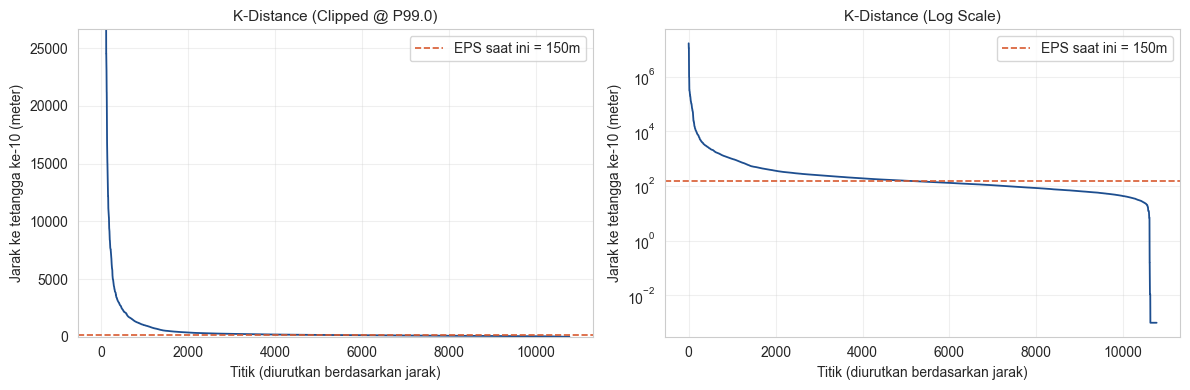

In [23]:
# ── 6.2.2 K-Distance Plot (Clipped + Log Scale) ───────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Config: upper percentile to clip extreme outliers that flatten the curve.
# Using 99th percentile keeps the elbow visible for most points.
clip_percentile = 99.0
clip_max = np.percentile(k_distances, clip_percentile)

# Config: safe epsilon for log scale to avoid log(0).
# Distances can be zero for identical points or dense clusters.
log_eps = 1e-3

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Clipped y-axis (linear scale).
axes[0].plot(k_distances, color="#1D4E8F", linewidth=1.3)
axes[0].axhline(
    y=EPS_METER, color="#D85A30", linestyle="--",
    label=f"EPS saat ini = {EPS_METER}m", linewidth=1.2
 )
axes[0].set_title(f"K-Distance (Clipped @ P{clip_percentile})", fontsize=11)
axes[0].set_xlabel("Titik (diurutkan berdasarkan jarak)")
axes[0].set_ylabel(f"Jarak ke tetangga ke-{MIN_SAMPLES} (meter)")
axes[0].set_ylim(0, clip_max)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Log scale to compress large distances and show elbow shape.
axes[1].plot(np.maximum(k_distances, log_eps), color="#1D4E8F", linewidth=1.3)
axes[1].axhline(
    y=max(EPS_METER, log_eps), color="#D85A30", linestyle="--",
    label=f"EPS saat ini = {EPS_METER}m", linewidth=1.2
 )
axes[1].set_title("K-Distance (Log Scale)", fontsize=11)
axes[1].set_xlabel("Titik (diurutkan berdasarkan jarak)")
axes[1].set_ylabel(f"Jarak ke tetangga ke-{MIN_SAMPLES} (meter)")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Tahap 7.3 — Tuning Grid DBSCAN (Auto Ranking)

Grid sederhana untuk mencari kombinasi EPS dan min_samples terbaik
berdasarkan Silhouette, Davies-Bouldin, dan noise ratio.

In [24]:
# ── 6.3 Tuning Grid DBSCAN (Auto Ranking) ─────────────────────────────
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from IPython.display import display

# Parameter grid (sesuaikan jika perlu)
eps_grid = [80, 100, 120, 150, 180, 200]
min_samples_grid = [4, 5, 6, 8]

results = []
coords = df[['x_utm', 'y_utm']].values

for eps in eps_grid:
    for ms in min_samples_grid:
        model = DBSCAN(eps=eps, min_samples=ms, metric='euclidean', algorithm='ball_tree', n_jobs=-1)
        labels = model.fit_predict(coords)
        n_noise_local = (labels == -1).sum()
        n_clustered_local = (labels >= 0).sum()
        n_clusters_local = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio_local = n_noise_local / len(labels) if len(labels) else 1.0

        sil = None
        dbi = None
        if n_clusters_local >= 2 and n_clustered_local > 0:
            X_eval = coords[labels >= 0]
            y_eval = labels[labels >= 0]
            sample_size = min(5000, len(y_eval))
            sil = float(silhouette_score(X_eval, y_eval, sample_size=sample_size, random_state=RANDOM_SEED))
            dbi = float(davies_bouldin_score(X_eval, y_eval))

        results.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters_local,
            "noise_ratio": round(noise_ratio_local * 100, 2),
            "silhouette": None if sil is None else round(sil, 4),
            "davies_bouldin": None if dbi is None else round(dbi, 4),
        })

df_grid = pd.DataFrame(results)
print("Hasil grid search (ringkas):")
display(df_grid)

# Ranking: prioritaskan silhouette tinggi, DB rendah, noise ratio rendah
df_rank = df_grid.copy()
df_rank['silhouette_rank'] = df_rank['silhouette'].fillna(-1)
df_rank['db_rank'] = df_rank['davies_bouldin'].fillna(9999)
df_rank = df_rank.sort_values(["silhouette_rank", "db_rank", "noise_ratio"], ascending=[False, True, True])
print("\nTop 10 rekomendasi parameter:")
display(df_rank.head(10))

Hasil grid search (ringkas):


,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin
0,80,4,432,37.38,0.3331,0.4810
1,80,5,323,43.85,0.3842,0.4761
2,80,6,245,49.96,0.3999,0.4373
3,80,8,161,59.79,0.4472,0.4440
4,100,4,366,29.60,0.2537,0.4682
5,100,5,278,35.40,0.2815,0.4759
6,100,6,239,39.66,0.2821,0.4937
7,100,8,175,48.81,0.3485,0.4693
8,120,4,319,24.48,0.1252,0.5065
9,120,5,256,28.58,0.1667,0.5128



Top 10 rekomendasi parameter:


,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,silhouette_rank,db_rank
3,80,8,161,59.79,0.4472,0.4440,0.4472,0.4440
2,80,6,245,49.96,0.3999,0.4373,0.3999,0.4373
1,80,5,323,43.85,0.3842,0.4761,0.3842,0.4761
7,100,8,175,48.81,0.3485,0.4693,0.3485,0.4693
0,80,4,432,37.38,0.3331,0.4810,0.3331,0.4810
11,120,8,174,39.84,0.3092,0.4866,0.3092,0.4866
6,100,6,239,39.66,0.2821,0.4937,0.2821,0.4937
5,100,5,278,35.40,0.2815,0.4759,0.2815,0.4759
4,100,4,366,29.60,0.2537,0.4682,0.2537,0.4682
15,150,8,139,31.43,0.2086,0.5359,0.2086,0.5359


---
## Tahap 8 — Simpan ke Feature Store

Feature Store adalah tabel terproses yang menjadi **satu-satunya sumber data** untuk:
- Training Random Forest (Notebook 02)
- Serving API (prediksi real-time)

Dengan memisahkan Feature Store dari raw data, kita memastikan:
- Training dan serving menggunakan fitur yang identik
- Tidak ada kebocoran logika preprocessing antara training dan production
- Jika data baru masuk, cukup jalankan ulang notebook ini

In [25]:
# ── 7.1 Tentukan kolom yang masuk Feature Store ───────────────────────
#
# Kolom identifier: untuk referensi
# Kolom koordinat: lat/lon asli + UTM untuk keperluan spasial
# Kolom cluster: hasil DBSCAN
# Kolom density: fitur geospasial
# Kolom atribut: fitur dari data usaha

# Kolom identifier
id_cols = ['id', 'name', CAT_COL]
id_cols = [c for c in id_cols if c in df.columns]

# Kolom koordinat
coord_cols = [LAT_COL, LON_COL, 'x_utm', 'y_utm']

# Kolom hasil clustering
cluster_cols = ['cluster_id', 'dist_to_cluster_centroid_m']

# Kolom density (fitur geospasial)
density_cols = [
    'competitor_density_500m',
    'competitor_density_1km',
    'same_category_density_500m',
    'nearest_neighbor_dist_m'
]

# Kolom atribut usaha
attr_cols = []
for col in ['rating', 'review_log', 'price_level']:
    if col in df.columns:
        attr_cols.append(col)

# Gabungkan semua kolom
feature_cols = id_cols + coord_cols + cluster_cols + density_cols + attr_cols
feature_cols = [c for c in feature_cols if c in df.columns]  # filter yang ada

df_feature_store = df[feature_cols].copy()

print(f"Kolom dalam Feature Store ({len(feature_cols)} total):")
for col in feature_cols:
    dtype = df_feature_store[col].dtype
    null_count = df_feature_store[col].isnull().sum()
    print(f"  {col:<35} {str(dtype):<10} null: {null_count}")

Kolom dalam Feature Store (16 total):
  id                                  int64      null: 0
  name                                str        null: 0
  source_category                     str        null: 0
  latitude                            float64    null: 0
  longitude                           float64    null: 0
  x_utm                               float64    null: 0
  y_utm                               float64    null: 0
  cluster_id                          int64      null: 0
  dist_to_cluster_centroid_m          float64    null: 0
  competitor_density_500m             int64      null: 0
  competitor_density_1km              int64      null: 0
  same_category_density_500m          int64      null: 0
  nearest_neighbor_dist_m             float64    null: 0
  rating                              float64    null: 0
  review_log                          float64    null: 0
  price_level                         int64      null: 0


In [26]:
# ── 7.2 Simpan Feature Store ──────────────────────────────────────────
df_feature_store.to_csv(FEATURE_STORE_PATH, index=False)
print(f"✓ Feature Store disimpan: {FEATURE_STORE_PATH}")
print(f"  Shape: {df_feature_store.shape}")
print(f"  Ukuran file: {os.path.getsize(FEATURE_STORE_PATH)/1024:.1f} KB")

print(f"\nSampel 3 baris Feature Store:")
df_feature_store.head(3)

✓ Feature Store disimpan: content/data/processed/feature_store.csv
  Shape: (10768, 16)
  Ukuran file: 1676.9 KB

Sampel 3 baris Feature Store:


,id,name,source_category,latitude,longitude,x_utm,y_utm,cluster_id,dist_to_cluster_centroid_m,competitor_density_500m,competitor_density_1km,same_category_density_500m,nearest_neighbor_dist_m,rating,review_log,price_level
0,43,Cindy Cosmetic (Cosmetics store),retail,1.069968,104.022610,391254.494424,118281.071759,-1,0.00000,75,114,13,0.000000,0.0,0.000000,0
1,60,Salsa Perfume Premium Seraya,retail,1.147871,104.015145,390426.713322,126893.316018,0,477.40577,392,877,47,10.101112,4.9,5.337538,0
2,68,Agen Resmi Minyak Kutus Kutus Batu Ampar,retail,1.156537,104.017022,390635.896275,127851.176922,-1,0.00000,40,392,5,3.672639,5.0,0.693147,0


In [27]:
# ── 7.3 Simpan Metadata Clustering ───────────────────────────────────
#
# Metadata wajib disimpan untuk:
# - Reproducibility: tahu persis kondisi saat model ini dilatih
# - Version control: bandingkan metrik antar run
# - Admin dashboard: ditampilkan saat trigger retraining
import os
import datetime

db_file_names = [os.path.basename(p) for p in db_files] if 'db_files' in globals() else []

metadata = {
    "notebook"         : "01_dbscan_clustering",
    "timestamp"        : datetime.datetime.now().isoformat(),
    "input": {
        "db_folder"     : DB_FOLDER,
        "db_files"      : db_file_names,
        "total_raw"     : int(total_raw),
        "total_valid"   : int(len(df)),
        "total_rejected": int(total_rejected)
    },
    "parameters": {
        "eps_meter"    : EPS_METER,
        "min_samples"  : MIN_SAMPLES,
        "crs_input"    : CRS_WGS84,
        "crs_output"   : CRS_UTM48N,
        "radius_500m"  : RADIUS_500M,
        "radius_1km"   : RADIUS_1KM
    },
    "results": {
        "n_clusters"         : int(n_clusters),
        "n_noise"            : int(n_noise),
        "n_clustered"        : int(n_clustered),
        "noise_ratio_pct"    : round(n_noise / len(df) * 100, 2),
        "silhouette_score"   : round(sil_score, 4) if sil_score else None,
        "davies_bouldin_idx" : round(db_score, 4)  if db_score  else None
    },
    "output": {
        "feature_store_path" : FEATURE_STORE_PATH,
        "feature_columns"    : feature_cols
    }
}

with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata disimpan: {METADATA_PATH}")
print(f"\nIsi metadata:")
print(json.dumps(metadata, indent=2))

✓ Metadata disimpan: content/models/clustering_metadata.json

Isi metadata:
{
  "notebook": "01_dbscan_clustering",
  "timestamp": "2026-05-10T21:29:57.777080",
  "input": {
    "db_folder": "content/data/raw",
    "db_files": [
      "Indonesia.Batam.Cosmetics.202410290644.db",
      "Indonesia.Batam.Hotel.202408042041.db",
      "Indonesia.Batam.Kesehatan.202408050759.db",
      "Indonesia.Batam.Kuliner.202406162232.db",
      "Indonesia.Batam.PT.202408042212.db",
      "Indonesia.Batam.School.202408060757.db",
      "Indonesia.Batam.Toko Bangunan.202408021219.db",
      "Indonesia.Batam.Toko Komputer.202410170720.db"
    ],
    "total_raw": 11094,
    "total_valid": 10768,
    "total_rejected": 326
  },
  "parameters": {
    "eps_meter": 150,
    "min_samples": 10,
    "crs_input": "EPSG:4326",
    "crs_output": "EPSG:32648",
    "radius_500m": 500,
    "radius_1km": 1000
  },
  "results": {
    "n_clusters": 118,
    "n_noise": 3935,
    "n_clustered": 6833,
    "noise_ratio_pct": 

---
## Ringkasan & Langkah Selanjutnya

### Yang sudah diselesaikan notebook ini:

| Tahap | Status | Output |
|---|---|---|
| Ingestion dari SQLite | ✓ | DataFrame raw |
| Validation Gate (4 aturan) | ✓ | `rejected_rows.csv` |
| Konversi WGS84 → UTM | ✓ | Kolom `x_utm`, `y_utm` |
| DBSCAN Clustering | ✓ | Kolom `cluster_id` |
| Evaluasi (Silhouette + DB Index) | ✓ | Tercatat di metadata |
| Hitung centroid & jarak | ✓ | Kolom `dist_to_cluster_centroid_m` |
| Hitung fitur density | ✓ | 4 kolom density |
| Simpan Feature Store | ✓ | `feature_store.csv` |
| Simpan Metadata | ✓ | `clustering_metadata.json` |

### Sebelum lanjut ke Notebook 02 (Random Forest), pastikan:

1. **Silhouette Score > 0.3** — jika tidak, tuning `EPS_METER` menggunakan k-distance graph
2. **Noise ratio < 30%** — jika lebih, kemungkinan `EPS` terlalu kecil atau `MIN_SAMPLES` terlalu besar
3. **Cluster masuk akal geografis** — periksa visualisasi, cluster harus terbentuk di area yang memang ramai (Nagoya Hill, Batam Center, Batu Aji, dll)
4. **Feature Store tidak ada null** — cek kolom `cluster_id` dan `dist_to_cluster_centroid_m`

### Panduan tuning cepat:

| Gejala | Solusi |
|---|---|
| Terlalu banyak noise (>40%) | Besarkan `EPS_METER` atau kecilkan `MIN_SAMPLES` |
| Semua jadi satu cluster besar | Kecilkan `EPS_METER` |
| Terlalu banyak cluster kecil | Besarkan `MIN_SAMPLES` |
| Silhouette Score negatif | `EPS` terlalu besar, cluster overlap |

### File output:
```
data/
├── raw/
│   └── places.db
└── processed/
    ├── feature_store.csv         ← input untuk Notebook 02
    ├── rejected_rows.csv         ← data yang ditolak Validation Gate
    ├── clustering_result.png     ← visualisasi sebaran cluster
    └── k_distance_graph.png      ← panduan tuning EPS
models/
└── clustering_metadata.json      ← metadata run ini
```

In [28]:
# ── Final Sanity Check ────────────────────────────────────────────────
# Jalankan cell ini terakhir untuk memastikan semua output tersedia

print("="*55)
print("  FINAL CHECK — Notebook 01 DBSCAN Clustering")
print("="*55)

checks = [
    (FEATURE_STORE_PATH, "Feature Store CSV"),
    (METADATA_PATH,      "Clustering Metadata JSON"),
    (f"{OUTPUT_DIR}/rejected_rows.csv",      "Rejected Rows Log"),
    (f"{OUTPUT_DIR}/clustering_result.png",  "Visualisasi Cluster"),
    (f"{OUTPUT_DIR}/k_distance_graph.png",   "K-Distance Graph"),
]

all_ok = True
for path, label in checks:
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    if not exists:
        all_ok = False
    size = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "—"
    print(f"  {status} {label:<30} {size}")

print("="*55)
print(f"  Cluster ID range : {df['cluster_id'].min()} s.d. {df['cluster_id'].max()}")
print(f"  Total data       : {len(df_feature_store):,} baris")
if sil_score:
    print(f"  Silhouette Score : {sil_score:.4f}")
    print(f"  Davies-Bouldin   : {db_score:.4f}")
print("="*55)

if all_ok:
    print("\n✓ Semua output tersedia. Lanjut ke Notebook 02: Random Forest Training.")
else:
    print("\n⚠ Ada output yang belum tersedia. Periksa cell di atas.")

  FINAL CHECK — Notebook 01 DBSCAN Clustering
  ✓ Feature Store CSV              1676.9 KB
  ✓ Clustering Metadata JSON       1.5 KB
  ✓ Rejected Rows Log              193.7 KB
  ✓ Visualisasi Cluster            137.2 KB
  ✓ K-Distance Graph               40.4 KB
  Cluster ID range : -1 s.d. 117
  Total data       : 10,768 baris
  Silhouette Score : 0.3424
  Davies-Bouldin   : 0.5229

✓ Semua output tersedia. Lanjut ke Notebook 02: Random Forest Training.


---
## Tahap 9 — Quality Gate DBSCAN

Pastikan konfigurasi DBSCAN sudah menghasilkan cluster yang layak sebelum lanjut ke Random Forest.
Gate ini tidak menghentikan proses, tapi memberi peringatan jika kualitas terlalu rendah.

In [29]:
# ── Quality Gate DBSCAN ───────────────────────────────────────────────
required_vars = ["n_clusters", "n_noise", "df"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    print(f"⚠ Variabel belum tersedia: {missing}")
    print("Jalankan Tahap 5 terlebih dahulu (DBSCAN).")
else:
    noise_ratio = n_noise / len(df) if len(df) > 0 else 1.0
    print("DBSCAN Quality Gate")
    print("-" * 40)
    print(f"Total data        : {len(df):,}")
    print(f"Jumlah cluster    : {n_clusters}")
    print(f"Noise ratio       : {noise_ratio*100:.1f}%")
    if 'sil_score' in globals() and sil_score is not None:
        print(f"Silhouette Score  : {sil_score:.4f}")
    else:
        print("Silhouette Score  : belum dihitung")

    if noise_ratio > 0.4:
        print("⚠ Noise ratio tinggi (>40%). Pertimbangkan menaikkan EPS_METER atau menurunkan MIN_SAMPLES.")
    if 'sil_score' in globals() and sil_score is not None and sil_score < 0.3:
        print("⚠ Silhouette Score < 0.3. Cluster kemungkinan overlap.")
    print("-" * 40)

DBSCAN Quality Gate
----------------------------------------
Total data        : 10,768
Jumlah cluster    : 118
Noise ratio       : 36.5%
Silhouette Score  : 0.3424
----------------------------------------


---
## Tahap 10 — Random Forest Training (Rekomendasi Lokasi)

Tahap ini membuat label proxy `High/Medium/Low` berdasarkan formula PRD,
lalu melatih model Random Forest dengan spatial split untuk menghindari data leakage.

### 10.1 Load Feature Store & Label Proxy

Ringkas: load feature store, buat hotspot score, dan label proxy.

In [30]:
# ── 9.1 Load Feature Store + Buat Label Proxy ─────────────────────────
import os
import numpy as np
import pandas as pd
from sklearn.neighbors import KernelDensity

df_fs = pd.read_csv(FEATURE_STORE_PATH)
print(f"Feature store loaded: {df_fs.shape[0]:,} baris × {df_fs.shape[1]} kolom")

required_cols = [
    "x_utm", "y_utm", "rating", "review_log",
    "competitor_density_500m", "same_category_density_500m",
    "nearest_neighbor_dist_m", "dist_to_cluster_centroid_m"
 ]
missing_cols = [c for c in required_cols if c not in df_fs.columns]
if missing_cols:
    raise ValueError(f"Kolom wajib untuk RF tidak ditemukan: {missing_cols}")

# Isi nilai null dengan median agar training stabil
for col in required_cols:
    df_fs[col] = df_fs[col].fillna(df_fs[col].median())

# --- Hotspot score via KDE (jika belum ada) ---
if "hotspot_score" not in df_fs.columns:
    coords = df_fs[["x_utm", "y_utm"]].values
    kde_bandwidth_m = 500.0
    kde = KernelDensity(bandwidth=kde_bandwidth_m, kernel="gaussian")
    kde.fit(coords)
    log_density = kde.score_samples(coords)
    df_fs["hotspot_score"] = np.exp(log_density)
    print("Hotspot score dibuat dengan KDE.")
else:
    print("Hotspot score sudah tersedia.")

# --- Saturation index (proxy) berdasarkan radius 500m ---
area_km2 = np.pi * (0.5 ** 2)
df_fs["saturation_index"] = df_fs["same_category_density_500m"] / area_km2

# --- Suitability score (proxy sesuai PRD) ---
df_fs["suitability_score"] = (
    df_fs["rating"] * 0.25 +
    df_fs["review_log"] * 0.20 +
    df_fs["hotspot_score"] * 0.25 -
    df_fs["same_category_density_500m"] * 0.20 -
    df_fs["saturation_index"] * 0.10
)

q1, q2 = df_fs["suitability_score"].quantile([0.33, 0.66])
df_fs["suitability_label"] = pd.cut(
    df_fs["suitability_score"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"]
)

print("Distribusi label:")
print(df_fs["suitability_label"].value_counts())

Feature store loaded: 10,768 baris × 16 kolom


Hotspot score dibuat dengan KDE.
Distribusi label:
suitability_label
High      3661
Low       3554
Medium    3553
Name: count, dtype: int64


### 10.1b Ringkasan Label (Clean Table)

Ringkas: tampilkan distribusi label dan ambang kuantil.

In [31]:
# ── 9.1b Ringkasan Label (Clean Output) ───────────────────────────────
from IPython.display import display

label_counts = df_fs["suitability_label"].value_counts(dropna=False)
label_pct = (label_counts / label_counts.sum() * 100).round(2)
label_summary = pd.DataFrame({"count": label_counts, "pct": label_pct})

thresholds = pd.DataFrame({"q1": [q1], "q2": [q2]})

display(label_summary)
display(thresholds)

,count,pct
suitability_label,,
High,3661,34.00
Low,3554,33.01
Medium,3553,33.00


,q1,q2
0,-7.320611,-1.63662


### 10.2 Spatial Split & Train Random Forest

Ringkas: split grid 1km untuk hindari leakage lalu training model.

In [32]:
# ── 9.2 Spatial Split + Train Random Forest ──────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Feature set untuk RF
rf_feature_cols = [
    "rating", "review_log", "hotspot_score",
    "competitor_density_500m", "same_category_density_500m",
    "nearest_neighbor_dist_m", "dist_to_cluster_centroid_m",
    "cluster_id"
 ]
rf_feature_cols = [c for c in rf_feature_cols if c in df_fs.columns]

X = df_fs[rf_feature_cols]
y = df_fs["suitability_label"]

# Spatial split berbasis grid 1km untuk menghindari leakage
grid_size_m = 1000
grid_x = (df_fs["x_utm"] // grid_size_m).astype(int)
grid_y = (df_fs["y_utm"] // grid_size_m).astype(int)
df_fs["grid_id"] = grid_x.astype(str) + "_" + grid_y.astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups=df_fs["grid_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1, 
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print(f"Training data: {X_train.shape}, Test data: {X_test.shape}")
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

f1_macro = f1_score(y_test, pred, average="macro")
cm = confusion_matrix(y_test, pred, labels=["Low", "Medium", "High"])
report_dict = classification_report(y_test, pred, output_dict=True)

print("F1 Macro:", round(f1_macro, 4))
print("Confusion Matrix (Low/Medium/High):")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, pred))

Training data: (8465, 8), Test data: (2303, 8)
F1 Macro: 0.9859
Confusion Matrix (Low/Medium/High):
[[713   7   0]
 [  5 796   3]
 [  0  18 761]]

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.98      0.99       779
         Low       0.99      0.99      0.99       720
      Medium       0.97      0.99      0.98       804

    accuracy                           0.99      2303
   macro avg       0.99      0.99      0.99      2303
weighted avg       0.99      0.99      0.99      2303



### 10.2b Evaluasi Model (Table & Visual)

Ringkas: metrik, confusion matrix, dan feature importance.

Ringkasan metrik:


,metric,value
0,f1_macro,0.9859
1,accuracy,0.9857



Classification report (ringkas):


,precision,recall,f1-score,support
Low,0.993036,0.990278,0.991655,720.000000
Medium,0.969549,0.990050,0.979692,804.000000
High,0.996073,0.976893,0.986390,779.000000
accuracy,0.985671,0.985671,0.985671,0.985671
macro avg,0.986220,0.985740,0.985913,2303.000000
weighted avg,0.985864,0.985671,0.985698,2303.000000



Confusion matrix (table):


,Low,Medium,High
Low,713,7,0
Medium,5,796,3
High,0,18,761


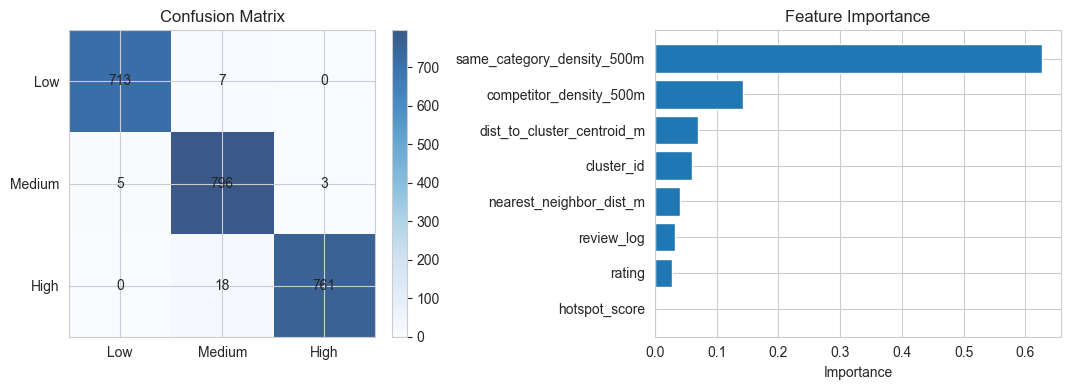

In [33]:
# ── 9.2b Evaluasi Model (Clean Output) ────────────────────────────────
from IPython.display import display
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    "metric": ["f1_macro", "accuracy"],
    "value": [round(f1_macro, 4), round(report_dict.get("accuracy", np.nan), 4)],
})

report_df = pd.DataFrame(report_dict).T
report_view = report_df.loc[
    ["Low", "Medium", "High", "accuracy", "macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"],
]

cm_df = pd.DataFrame(cm, index=["Low", "Medium", "High"], columns=["Low", "Medium", "High"])

print("Ringkasan metrik:")
display(metrics_df)
print("\nClassification report (ringkas):")
display(report_view)
print("\nConfusion matrix (table):")
display(cm_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix heatmap
ax = axes[0]
im = ax.imshow(cm, cmap="Blues", alpha=0.8)
ax.set_title("Confusion Matrix")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(["Low", "Medium", "High"])
ax.set_yticklabels(["Low", "Medium", "High"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Feature importance
ax = axes[1]
importances = pd.Series(rf.feature_importances_, index=rf_feature_cols).sort_values(ascending=True)
ax.barh(importances.index, importances.values)
ax.set_title("Feature Importance")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

### 10.2c SHAP Explainability (Global + Local)

Ringkas: interpretasi global dan contoh lokal prediksi.

SHAP Global Importance (mean |SHAP|):


,feature,mean_abs_shap
0,same_category_density_500m,0.312573
1,competitor_density_500m,0.054601
2,dist_to_cluster_centroid_m,0.030567
3,rating,0.025547
4,review_log,0.022204
5,cluster_id,0.020844
6,nearest_neighbor_dist_m,0.010961
7,hotspot_score,0.000000


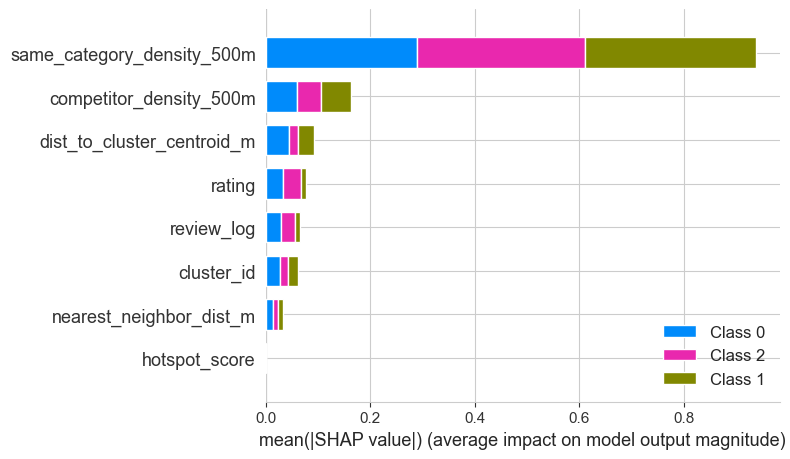

Local explanation sample — Pred: High


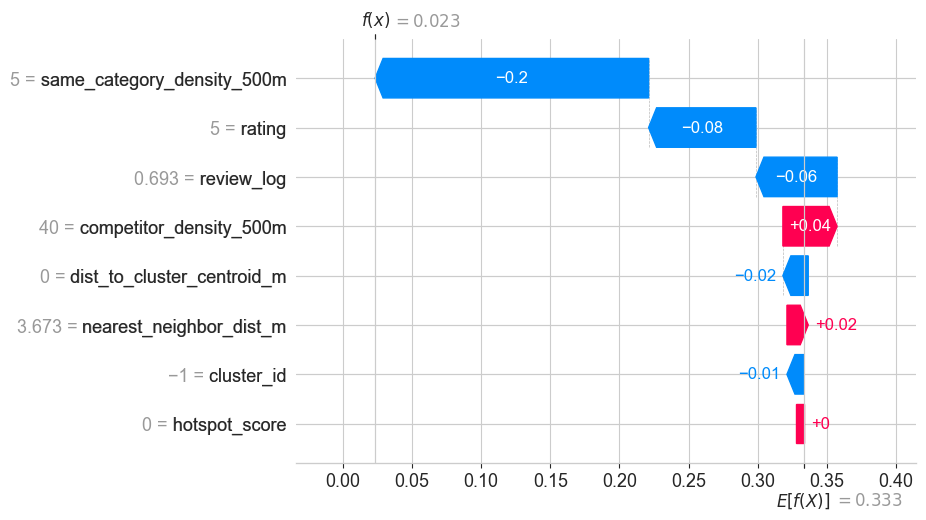

✓ SHAP importance disimpan: content/data/processed\rf_shap_importance.csv


In [34]:
# ── 9.2c SHAP Explainability (Global + Local) ─────────────────────────
import os
import numpy as np
from IPython.display import display

try:
    import shap
except ImportError:
    shap = None

if shap is None:
    print("SHAP belum terpasang. Jalankan: %pip install shap")
else:
    shap.initjs()

    # Batasi sampel agar proses lebih cepat
    max_samples = 300
    if len(X_test) > max_samples:
        X_shap = X_test.sample(max_samples, random_state=RANDOM_SEED)
    else:
        X_shap = X_test.copy()

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_shap)

    # --- Global importance (mean |SHAP|) ---
    shap_values_list = None
    if isinstance(shap_values, list):
        abs_means = [
            pd.DataFrame(vals, columns=X_shap.columns).abs().mean(axis=0)
            for vals in shap_values
        ]
        shap_importance = pd.concat(abs_means, axis=1).mean(axis=1).sort_values(ascending=False)
        shap_values_list = shap_values
    else:
        shap_array = np.array(shap_values)
        if shap_array.ndim == 3:
            # Shape: (n_samples, n_features, n_classes)
            shap_importance = pd.Series(
                np.mean(np.abs(shap_array), axis=(0, 2)),
                index=X_shap.columns
            ).sort_values(ascending=False)
            shap_values_list = [shap_array[:, :, i] for i in range(shap_array.shape[2])]
        else:
            shap_importance = pd.Series(
                np.mean(np.abs(shap_array), axis=0),
                index=X_shap.columns
            ).sort_values(ascending=False)
            shap_values_list = shap_array

    shap_importance_df = shap_importance.reset_index()
    shap_importance_df.columns = ["feature", "mean_abs_shap"]

    print("SHAP Global Importance (mean |SHAP|):")
    display(shap_importance_df)

    # Plot ringkas global
    shap.summary_plot(shap_values_list, X_shap, show=True)

    # --- Local explanation (contoh 1 baris) ---
    idx_candidates = np.where(pred == "High")[0]
    row_idx = int(idx_candidates[0]) if len(idx_candidates) > 0 else 0
    x_row = X_test.iloc[[row_idx]]

    shap_row = explainer.shap_values(x_row)
    if isinstance(shap_row, list):
        class_labels = ["Low", "Medium", "High"]
        pred_class = pred[row_idx]
        class_idx = class_labels.index(pred_class) if pred_class in class_labels else 0
        values = shap_row[class_idx][0]
        base_value = explainer.expected_value[class_idx]
    else:
        shap_row_array = np.array(shap_row)
        if shap_row_array.ndim == 3:
            class_labels = ["Low", "Medium", "High"]
            pred_class = pred[row_idx]
            class_idx = class_labels.index(pred_class) if pred_class in class_labels else 0
            values = shap_row_array[0, :, class_idx]
            if isinstance(explainer.expected_value, (list, np.ndarray)):
                base_value = explainer.expected_value[class_idx]
            else:
                base_value = explainer.expected_value
        else:
            values = shap_row_array[0]
            base_value = explainer.expected_value

    explanation = shap.Explanation(
        values=values,
        base_values=base_value,
        data=x_row.iloc[0].values,
        feature_names=x_row.columns.tolist(),
    )

    print(f"Local explanation sample — Pred: {pred[row_idx]}")
    shap.plots.waterfall(explanation, max_display=12)

    # --- Simpan output ---
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    shap_importance_path = os.path.join(OUTPUT_DIR, "rf_shap_importance.csv")
    shap_importance_df.to_csv(shap_importance_path, index=False)
    print(f"✓ SHAP importance disimpan: {shap_importance_path}")

### 10.3 Simpan Model & Metadata

Ringkas: simpan model RF dan metadata evaluasi.

In [35]:
# ── 9.3 Simpan Model + Metadata ──────────────────────────────────────
import os
import glob
import json
import joblib
import datetime

MODEL_DIR = "content/models"
os.makedirs(MODEL_DIR, exist_ok=True)

existing_models = sorted(glob.glob(os.path.join(MODEL_DIR, "rf_location_reco_v*.joblib")))
version = len(existing_models) + 1
model_path = os.path.join(MODEL_DIR, f"rf_location_reco_v{version}.joblib")
joblib.dump(rf, model_path)

rf_metadata_path = os.path.join(MODEL_DIR, "rf_metadata.json")
rf_metadata = {
    "notebook"         : "02_random_forest_training",
    "timestamp"        : datetime.datetime.now().isoformat(),
    "model_path"       : model_path,
    "features"         : rf_feature_cols,
    "parameters"       : {
        "n_estimators"    : 300,
        "class_weight"    : "balanced",
        "random_seed"     : RANDOM_SEED,
        "spatial_split"   : "grid_1km_group_shuffle"
    },
    "metrics"          : {
        "f1_macro"        : round(f1_macro, 4),
        "confusion_matrix": cm.tolist(),
        "report"          : report_dict
    }
}

with open(rf_metadata_path, "w") as f:
    json.dump(rf_metadata, f, indent=2)

print(f"✓ Model disimpan: {model_path}")
print(f"✓ Metadata disimpan: {rf_metadata_path}")

✓ Model disimpan: content/models\rf_location_reco_v24.joblib
✓ Metadata disimpan: content/models\rf_metadata.json
